In [14]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

In [24]:
# Setting global
plt.style.use("seaborn-v0_8-whitegrid")   
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(2025)

In [61]:
ata_2024 = pd.read_csv("C:/Users/ASUS/Downloads/inflasi 2024.csv")
data_2025 = pd.read_csv("C:/Users/ASUS/Downloads/inflasi 2025.csv")
 
data_2024.columns = ["provinsi", "bulan", "inflasi"]
data_2025.columns = ["provinsi", "bulan", "inflasi"]
 
urutan_bulan = [
    "Januari", "Februari", "Maret", "April",
    "Mei", "Juni", "Juli", "Agustus",
    "September", "Oktober", "November", "Desember"
]
 
data_2024["bulan"] = pd.Categorical(data_2024["bulan"], categories=urutan_bulan, ordered=True)
data_2025["bulan"] = pd.Categorical(data_2025["bulan"], categories=urutan_bulan, ordered=True)
 
data_2025 = data_2025.dropna(subset=["inflasi"]).reset_index(drop=True)
data_2024 = data_2024.dropna(subset=["inflasi"]).reset_index(drop=True)
 
provinsi_list = sorted(data_2025["provinsi"].unique())
bulan_list    = urutan_bulan
 
provinsi_idx  = pd.Categorical(data_2025["provinsi"], categories=provinsi_list).codes
bulan_idx     = pd.Categorical(data_2025["bulan"], categories=urutan_bulan, ordered=True).codes
 
n_provinsi = len(provinsi_list)
n_bulan    = len(bulan_list)
y_obs      = data_2025["inflasi"].values
 
print(f"\nData 2025 berhasil diload:")
print(f"  Jumlah provinsi  : {n_provinsi}")
print(f"  Jumlah bulan     : {n_bulan}")
print(f"  Total observasi  : {len(y_obs)}")
print(f"  Mean inflasi 2025: {y_obs.mean():.4f}%")
print(f"  SD inflasi 2025  : {y_obs.std():.4f}%")


Data 2025 berhasil diload:
  Jumlah provinsi  : 38
  Jumlah bulan     : 12
  Total observasi  : 456
  Mean inflasi 2025: 0.2510%
  SD inflasi 2025  : 0.8379%


In [ ]:
ata_2024 = pd.read_csv("C:/Users/ASUS/Downloads/inflasi 2024.csv")
data_2025 = pd.read_csv("C:/Users/ASUS/Downloads/inflasi 2025.csv")
 
data_2024.columns = ["provinsi", "bulan", "inflasi"]
data_2025.columns = ["provinsi", "bulan", "inflasi"]
 
urutan_bulan = [
    "Januari", "Februari", "Maret", "April",
    "Mei", "Juni", "Juli", "Agustus",
    "September", "Oktober", "November", "Desember"
]
 
data_2024["bulan"] = pd.Categorical(data_2024["bulan"], categories=urutan_bulan, ordered=True)
data_2025["bulan"] = pd.Categorical(data_2025["bulan"], categories=urutan_bulan, ordered=True)
 
data_2025 = data_2025.dropna(subset=["inflasi"]).reset_index(drop=True)
data_2024 = data_2024.dropna(subset=["inflasi"]).reset_index(drop=True)
 
provinsi_list = sorted(data_2024["provinsi"].unique())
bulan_list    = urutan_bulan
 
provinsi_idx  = pd.Categorical(data_2024["provinsi"], categories=provinsi_list).codes
bulan_idx     = pd.Categorical(data_2024["bulan"], categories=urutan_bulan, ordered=True).codes
 
n_provinsi = len(provinsi_list)
n_bulan    = len(bulan_list)
y_obs      = data_2024["inflasi"].values
 
print(f"\nData 2024 berhasil diload:")
print(f"  Jumlah provinsi  : {n_provinsi}")
print(f"  Jumlah bulan     : {n_bulan}")
print(f"  Total observasi  : {len(y_obs)}")
print(f"  Mean inflasi 2024: {y_obs.mean():.4f}%")
print(f"  SD inflasi 2024  : {y_obs.std():.4f}%")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\766464072.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


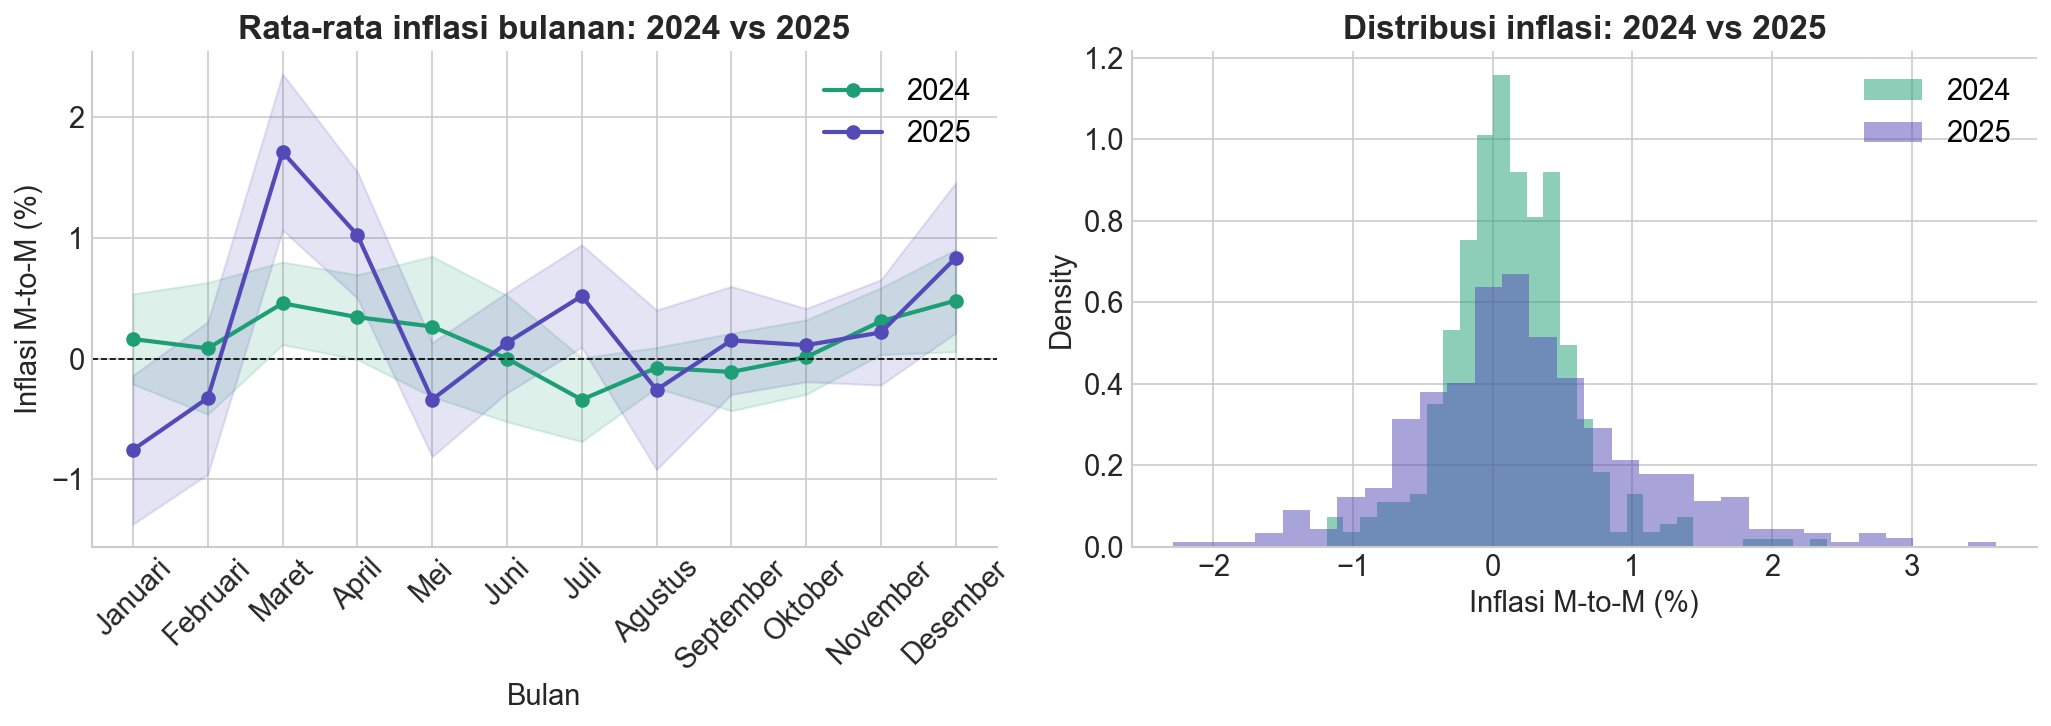

EDA selesai.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Tren bulanan 2024 vs 2025 ---
for tahun, df, warna in [("2024", data_2024, "#1D9E75"),
                          ("2025", data_2025, "#534AB7")]:
    grp = df.groupby("bulan", observed=True)["inflasi"]
    mn  = grp.mean()
    sd  = grp.std()
    axes[0].plot(urutan_bulan, mn.values, marker="o",
                 label=tahun, color=warna, linewidth=2)
    axes[0].fill_between(urutan_bulan,
                         (mn - sd).values, (mn + sd).values,
                         alpha=0.15, color=warna)

axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Rata-rata inflasi bulanan: 2024 vs 2025", fontweight="bold")
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Inflasi M-to-M (%)")
axes[0].legend(labelcolor="black", framealpha=1,        # ← tambahan
               edgecolor="gray", facecolor="white")     # ← tambahan
axes[0].tick_params(axis="x", rotation=45)

# --- Plot 2: Distribusi inflasi per tahun ---
axes[1].hist(data_2024["inflasi"].dropna(), bins=30, alpha=0.5,
             color="#1D9E75", label="2024", density=True)
axes[1].hist(data_2025["inflasi"].dropna(), bins=30, alpha=0.5,
             color="#534AB7", label="2025", density=True)
axes[1].set_title("Distribusi inflasi: 2024 vs 2025", fontweight="bold")
axes[1].set_xlabel("Inflasi M-to-M (%)")
axes[1].set_ylabel("Density")
axes[1].legend(labelcolor="black", framealpha=1,        # ← tambahan
               edgecolor="gray", facecolor="white")     # ← tambahan

plt.tight_layout()
plt.savefig("fig0_eda.png", dpi=300, bbox_inches="tight")
plt.show()
print("EDA selesai.")

In [45]:
# ── PRIOR ELICITATION DARI DATA 2024 ─────────────────────────────────────
print("\n=== PRIOR ELICITATION DARI DATA 2024 ===")

# Hitung statistik dari data 2024 sebagai dasar prior informatif
mu_prior_informatif   = data_2024["inflasi"].mean()
sd_prior_informatif   = data_2024["inflasi"].std()

# Variasi antar provinsi dari 2024
prov_means_2024 = data_2024.groupby("provinsi")["inflasi"].mean()
sp_prior = prov_means_2024.std()   # SD antar provinsi

# Variasi antar bulan dari 2024
bln_means_2024 = data_2024.groupby("bulan", observed=True)["inflasi"].mean()
sb_prior = bln_means_2024.std()    # SD antar bulan

# Residual (setelah dikurangi efek provinsi dan bulan)
sigma_prior = data_2024["inflasi"].std() * 0.6  # estimasi kasar residual

print(f"  μ_global prior  : Normal({mu_prior_informatif:.4f}, {sd_prior_informatif:.4f})")
print(f"  σ_provinsi prior: HalfNormal({sp_prior:.4f})")
print(f"  σ_bulan prior   : HalfNormal({sb_prior:.4f})")
print(f"  σ_resid prior   : HalfNormal({sigma_prior:.4f})")
print(f"\n  Sumber: data inflasi 2024 ({len(data_2024)} observasi)")


=== PRIOR ELICITATION DARI DATA 2024 ===
  μ_global prior  : Normal(0.1319, 0.4600)
  σ_provinsi prior: HalfNormal(0.0741)
  σ_bulan prior   : HalfNormal(0.2494)
  σ_resid prior   : HalfNormal(0.2760)

  Sumber: data inflasi 2024 (456 observasi)


In [48]:
def buat_model(prior_type="informatif", likelihood_type="normal",
               prov_idx=None, bln_idx=None, y=None,
               n_prov=38, n_bln=12):
    """
    Buat model hierarki Bayesian.

    prior_type      : 'informatif' | 'weak' | 'flat'
    likelihood_type : 'normal' | 'student'
    """

    # --- Pilih nilai prior berdasarkan skenario ---
    if prior_type == "informatif":
        mu_mean   = mu_prior_informatif
        mu_sd     = sd_prior_informatif
        sp_scale  = sp_prior
        sb_scale  = sb_prior
        sigma_scale = sigma_prior

    elif prior_type == "weak":
        mu_mean, mu_sd = 0.00, 1.00
        sp_scale, sb_scale = 0.50, 0.50
        sigma_scale = 0.50

    else:  # flat / non-informatif
        mu_mean, mu_sd = 0.00, 10.0
        sp_scale, sb_scale = 2.00, 2.00
        sigma_scale = 2.00

    with pm.Model() as model:

        # --- Hyperprior global ---
        mu_global = pm.Normal("mu_global", mu=mu_mean, sigma=mu_sd)

        # --- Variasi antar provinsi dan bulan ---
        sigma_prov  = pm.HalfNormal("sigma_prov",  sigma=sp_scale)
        sigma_bulan = pm.HalfNormal("sigma_bulan", sigma=sb_scale)

        # --- Efek random provinsi (non-centered parameterization) ---
        alpha_raw = pm.Normal("alpha_raw", mu=0, sigma=1, shape=n_prov)
        alpha_p   = pm.Deterministic("alpha_p", alpha_raw * sigma_prov)

        # --- Efek random bulan (non-centered parameterization) ---
        beta_raw  = pm.Normal("beta_raw",  mu=0, sigma=1, shape=n_bln)
        beta_t    = pm.Deterministic("beta_t",  beta_raw  * sigma_bulan)

        # --- Mean struktural ---
        mu_obs = mu_global + alpha_p[prov_idx] + beta_t[bln_idx]

        # --- Likelihood ---
        if likelihood_type == "normal":
            sigma_resid = pm.HalfNormal("sigma_resid", sigma=sigma_scale)
            y_hat = pm.Normal("y_hat", mu=mu_obs,
                              sigma=sigma_resid, observed=y)

        else:  # Student-t: robust terhadap outlier
            sigma_resid = pm.HalfNormal("sigma_resid", sigma=sigma_scale)
            nu          = pm.Gamma("nu", alpha=2, beta=0.1)
            y_hat       = pm.StudentT("y_hat", nu=nu, mu=mu_obs,
                                      sigma=sigma_resid, observed=y)

    return model

In [49]:
skenario = [
    ("informatif", "normal",  "M1: Informatif + Normal"),
    ("weak",       "normal",  "M2: Weak + Normal"),
    ("flat",       "normal",  "M3: Flat + Normal"),
    ("informatif", "student", "M4: Informatif + Student-t"),
    ("weak",       "student", "M5: Weak + Student-t"),
    ("flat",       "student", "M6: Flat + Student-t"),
]
 
idata_all = {}
 
for prior, lhood, nama in skenario:
    print(f"\n{'='*50}")
    print(f"Fitting {nama} ...")
    print(f"{'='*50}")
 
    model = buat_model(
        prior_type      = prior,
        likelihood_type = lhood,
        prov_idx        = provinsi_idx,
        bln_idx         = bulan_idx,
        y               = y_obs,
        n_prov          = n_provinsi,
        n_bln           = n_bulan
    )

    with model:
        idata = pm.sample(
            draws=2000, tune=2000, chains=4,
            target_accept=0.95, random_seed=2025,
            progressbar=True, return_inferencedata=True
        )
        pm.compute_log_likelihood(idata)
        pm.sample_posterior_predictive(
            idata,
            extend_inferencedata=True,
            random_seed=2025
        )
 
    idata_all[nama] = idata
    print(f"{nama} selesai.")
 
print("\n\nSemua 6 model selesai di-fitting!")


Fitting M1: Informatif + Normal ...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, sigma_prov, sigma_bulan, alpha_raw, beta_raw, sigma_resid]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 22 seconds.


Output()

...

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 35 seconds.


Output()

Sampling: [y_hat]


Output()

M6: Flat + Student-t selesai.


Semua 6 model selesai di-fitting!



=== CEK KONVERGENSI MODEL 1 ===
               mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu_global      0.24   0.161   -0.019     0.49       940      1617  1.00   
sigma_prov   0.0227  0.0174   0.0019    0.055      5156      3667  1.00   
sigma_bulan   0.586   0.093     0.46     0.75      1995      3169  1.00   
sigma_resid  0.5288  0.0179      0.5     0.56     11951      5813  1.00   

            mcse_mean  mcse_sd  
mu_global      0.0052    0.004  
sigma_prov     0.0002  0.00017  
sigma_bulan    0.0021   0.0016  
sigma_resid   0.00016  0.00012  


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\2363699210.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


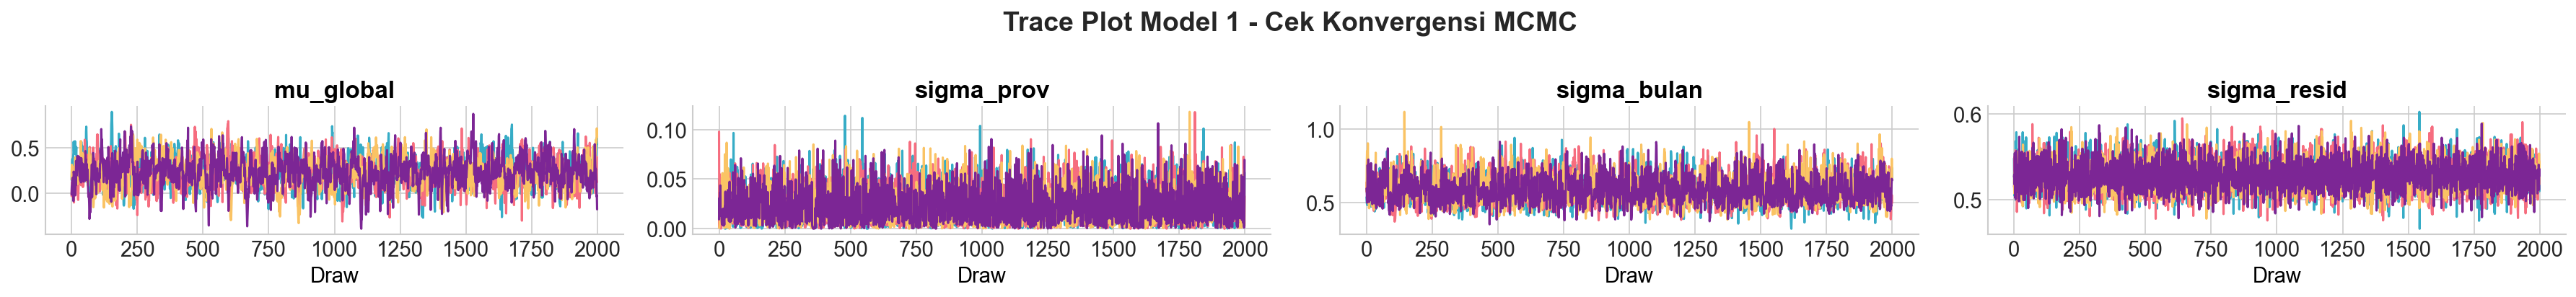


Parameter dengan R-hat > 1.01 (bermasalah):
  mu_global: 1.0018 ✓
  sigma_prov: 1.0004 ✓
  sigma_bulan: 1.0009 ✓
  sigma_resid: 1.0003 ✓


In [51]:
print("\n=== CEK KONVERGENSI MODEL 1 ===")
idata_m1 = idata_all["M1: Informatif + Normal"]
 
summary_m1 = az.summary(
    idata_m1,
    var_names=["mu_global", "sigma_prov", "sigma_bulan", "sigma_resid"]
)
print(summary_m1)
 
az.plot_trace(
    idata_m1,
    var_names=["mu_global", "sigma_prov", "sigma_bulan", "sigma_resid"]
)
plt.suptitle("Trace Plot Model 1 - Cek Konvergensi MCMC", y=1.02)
plt.tight_layout()
plt.savefig("fig_trace_m1.png", dpi=300, bbox_inches="tight")
plt.show()
 
rhats = az.rhat(idata_m1)
print("\nParameter dengan R-hat > 1.01 (bermasalah):")
for var in ["mu_global", "sigma_prov", "sigma_bulan", "sigma_resid"]:
    rhat_val = float(rhats[var].values)
    flag = "← PERLU PERHATIAN" if rhat_val > 1.01 else "✓"
    print(f"  {var}: {rhat_val:.4f} {flag}")


Shape y_rep M1 : (8000, 456)
Shape y_rep M4 : (8000, 456)
Shape y_obs    : (456,)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\138681282.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


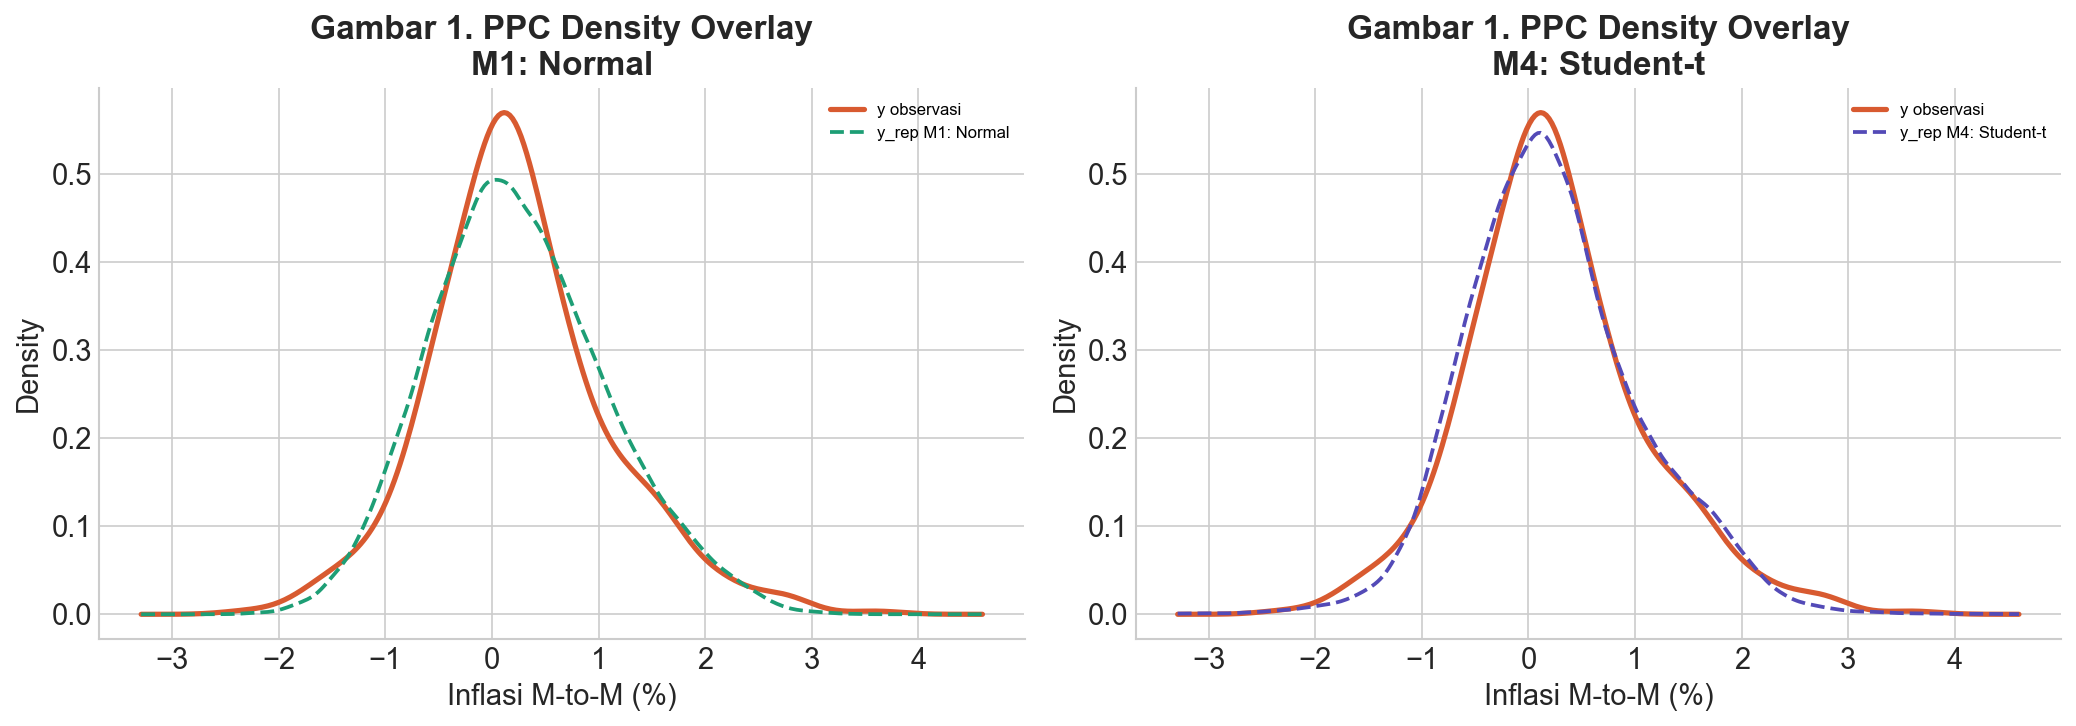

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\138681282.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


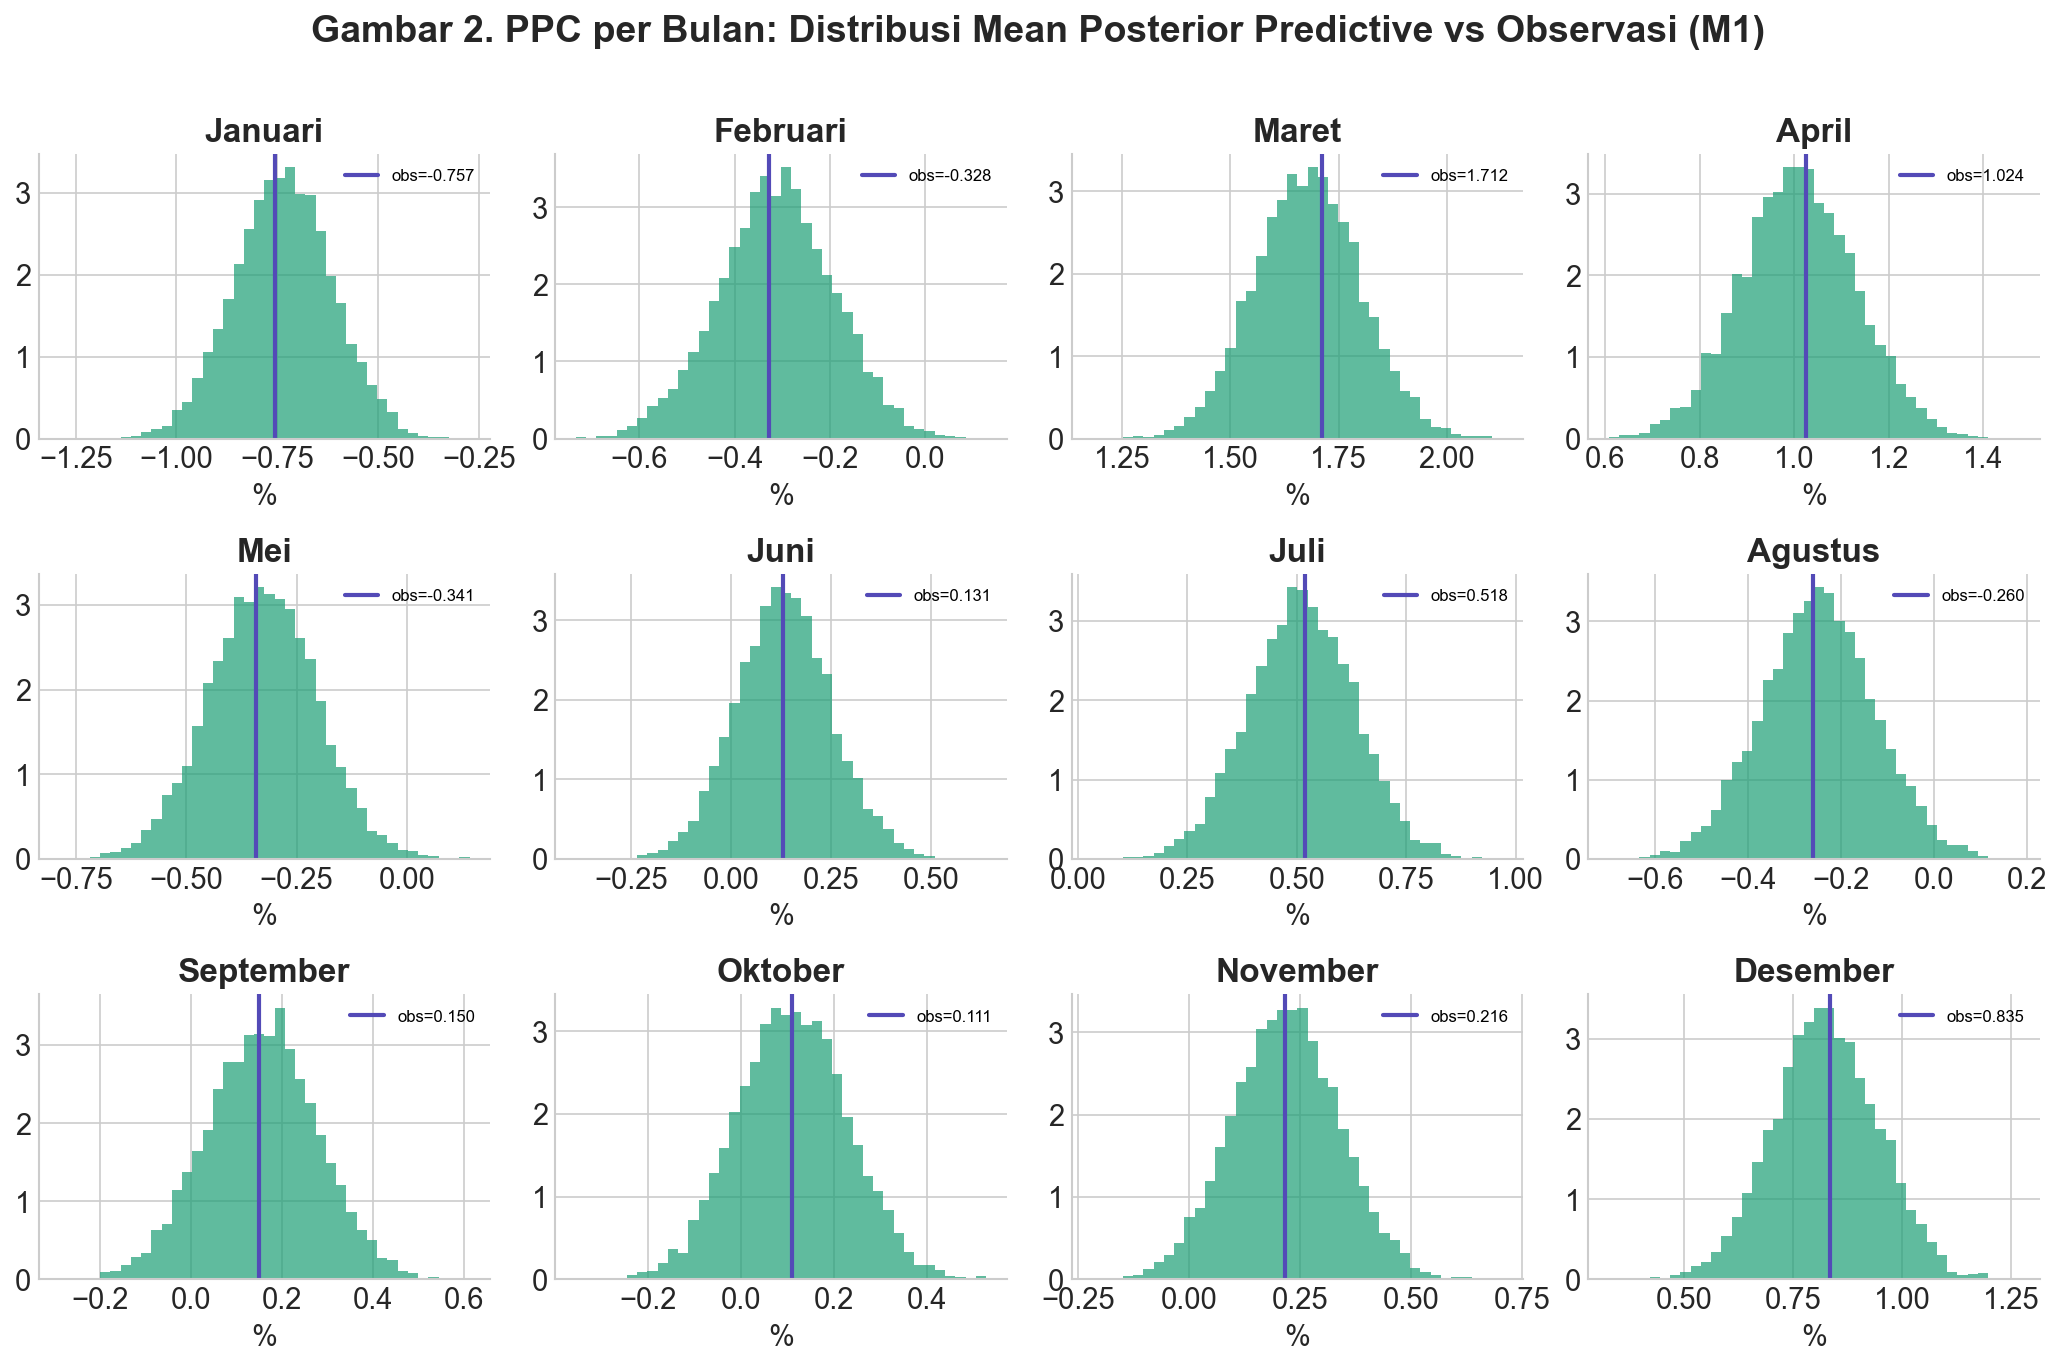


=== POSTERIOR PREDICTIVE P-VALUE (PPP) ===
Statistik       M1 Normal   M4 Student-t
----------------------------------------
PPP mean         0.5021 ✓ OK       0.3247 ✓ OK
PPP sd           0.4514 ✓ OK       0.5374 ✓ OK
PPP max          0.0076 ← ATN       0.3916 ✓ OK
PPP min          0.0858 ← ATN       0.6919 ✓ OK

Coverage 95% (M1 Normal): 95.0%  (ideal ~95%)

Coverage 95% (M4 Student-t): 95.2%  (ideal ~95%)


In [52]:
def get_yrep(idata, n_obs):
    """Ambil y_rep dari posterior_predictive, reshape ke (n_samples, n_obs)."""
    y_rep = idata.posterior_predictive["y_hat"].values
    return y_rep.reshape(-1, n_obs)
    
# ── 6.0  Siapkan y_rep untuk M1 dan M4 ─────────────────────────────────────
y_rep_m1 = get_yrep(idata_all["M1: Informatif + Normal"],    len(y_obs))
y_rep_m4 = get_yrep(idata_all["M4: Informatif + Student-t"], len(y_obs))

print(f"\nShape y_rep M1 : {y_rep_m1.shape}")
print(f"Shape y_rep M4 : {y_rep_m4.shape}")
print(f"Shape y_obs    : {y_obs.shape}")

# ── 6.1  PPC Density Overlay — M1 vs M4 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_rep, nama, warna in [
    (axes[0], y_rep_m1, "M1: Normal",    "#1D9E75"),
    (axes[1], y_rep_m4, "M4: Student-t", "#534AB7"),
]:
    kde_rep = stats.gaussian_kde(y_rep[:200].flatten())
    kde_obs = stats.gaussian_kde(y_obs)
    x_grid  = np.linspace(y_obs.min() - 1, y_obs.max() + 1, 300)
    ax.plot(x_grid, kde_obs(x_grid), color="#D85A30", linewidth=2.5, label="y observasi")
    ax.plot(x_grid, kde_rep(x_grid), color=warna,     linewidth=1.8,
            linestyle="--", label=f"y_rep {nama}")
    ax.set_title(f"Gambar 1. PPC Density Overlay\n{nama}", fontweight="bold")
    ax.set_xlabel("Inflasi M-to-M (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, labelcolor="black",       # ← tambahan
              facecolor="white", framealpha=1,      # ← tambahan
              edgecolor="gray")                     # ← tambahan

plt.tight_layout()
plt.savefig("fig1_ppc_density.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 6.2  PPC per bulan — M1 (referensi) ────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for i, bln in enumerate(urutan_bulan):
    mask      = bulan_idx == i
    y_bln     = y_obs[mask]
    rep_means = y_rep_m1[:, mask].mean(axis=1)
    obs_mean  = y_bln.mean()

    axes[i].hist(rep_means, bins=40, color="#1D9E75", alpha=0.7, density=True)
    axes[i].axvline(obs_mean, color="#534AB7", linewidth=2, label=f"obs={obs_mean:.3f}")
    axes[i].set_title(bln, fontweight="bold")
    axes[i].legend(fontsize=8, labelcolor="black",  # ← tambahan
                   facecolor="white", framealpha=1, # ← tambahan
                   edgecolor="gray")                # ← tambahan
    axes[i].set_xlabel("%")

plt.suptitle(
    "Gambar 2. PPC per Bulan: Distribusi Mean Posterior Predictive vs Observasi (M1)",
    fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig2_ppc_bulan.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 6.3  Posterior Predictive P-value — M1 vs M4 side-by-side ──────────────
def hitung_ppp(y_rep, y_obs):
    return {
        "mean": np.mean(y_rep.mean(axis=1) > y_obs.mean()),
        "sd"  : np.mean(y_rep.std(axis=1)  > y_obs.std()),
        "max" : np.mean(y_rep.max(axis=1)  > y_obs.max()),
        "min" : np.mean(y_rep.min(axis=1)  < y_obs.min()),
    }

ppp_m1 = hitung_ppp(y_rep_m1, y_obs)
ppp_m4 = hitung_ppp(y_rep_m4, y_obs)

print("\n=== POSTERIOR PREDICTIVE P-VALUE (PPP) ===")
print(f"{'Statistik':<12} {'M1 Normal':>12} {'M4 Student-t':>14}")
print("-" * 40)
for k in ["mean", "sd", "max", "min"]:
    flag_m1 = "✓ OK" if 0.1 < ppp_m1[k] < 0.9 else "← ATN"
    flag_m4 = "✓ OK" if 0.1 < ppp_m4[k] < 0.9 else "← ATN"
    print(f"PPP {k:<8} {ppp_m1[k]:>10.4f} {flag_m1}   {ppp_m4[k]:>10.4f} {flag_m4}")

# ── 6.4  Coverage 95% — M1 vs M4 ───────────────────────────────────────────
for y_rep, nama in [(y_rep_m1, "M1 Normal"), (y_rep_m4, "M4 Student-t")]:
    lo95     = np.percentile(y_rep, 2.5,  axis=0)
    hi95     = np.percentile(y_rep, 97.5, axis=0)
    coverage = np.mean((y_obs >= lo95) & (y_obs <= hi95))
    print(f"\nCoverage 95% ({nama}): {coverage*100:.1f}%  (ideal ~95%)")

# Simpan variabel y_rep M1 dengan nama asli untuk kompatibilitas bagian lain
y_rep = y_rep_m1


=== Q-Q PLOT BAYESIAN & ROOTOGRAM ===


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\1687384677.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


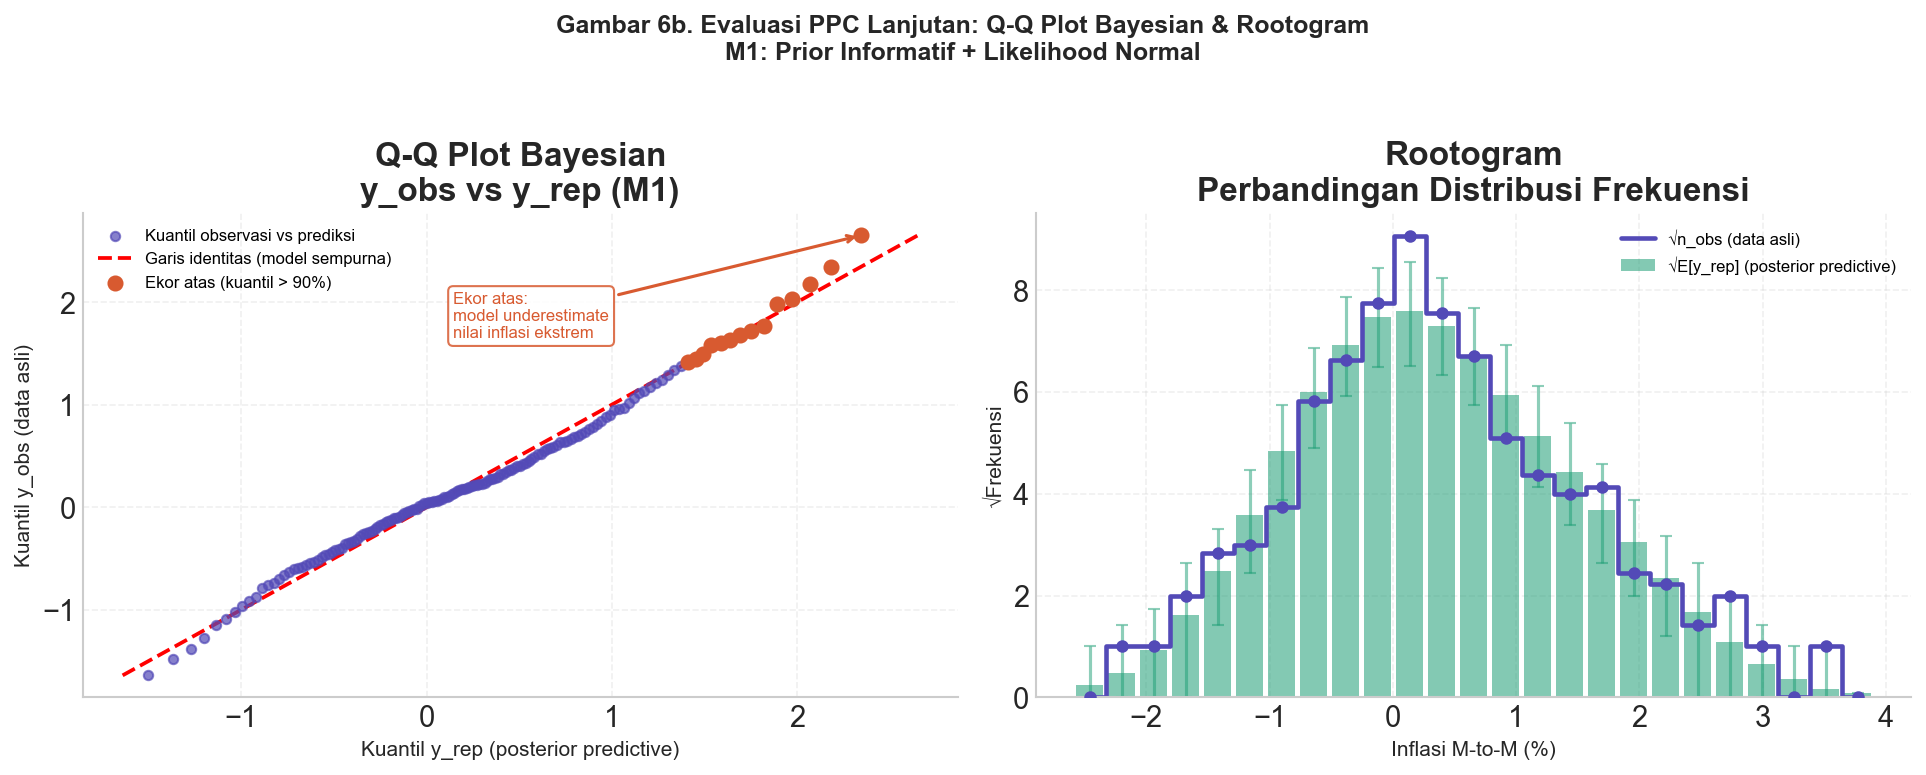

Tersimpan: fig6_qq_rootogram.png


In [53]:
print("\n=== Q-Q PLOT BAYESIAN & ROOTOGRAM ===")

rng         = np.random.default_rng(2025)
idx_sample  = rng.choice(y_rep.shape[0], 500, replace=False)
y_rep_flat  = y_rep[idx_sample].flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel kiri: Q-Q Plot Bayesian
quantiles = np.linspace(0.01, 0.99, 150)
q_obs     = np.quantile(y_obs,      quantiles)
q_rep     = np.quantile(y_rep_flat, quantiles)
ref_min   = min(q_rep.min(), q_obs.min())
ref_max   = max(q_rep.max(), q_obs.max())

axes[0].scatter(q_rep, q_obs, s=20, color="#534AB7", alpha=0.7, zorder=3,
                label="Kuantil observasi vs prediksi")
axes[0].plot([ref_min, ref_max], [ref_min, ref_max], "r--", linewidth=1.8,
             label="Garis identitas (model sempurna)")

deviate_mask = quantiles > 0.90
axes[0].scatter(q_rep[deviate_mask], q_obs[deviate_mask],
                s=45, color="#D85A30", zorder=4, label="Ekor atas (kuantil > 90%)")
axes[0].set_xlabel("Kuantil y_rep (posterior predictive)", fontsize=10)
axes[0].set_ylabel("Kuantil y_obs (data asli)", fontsize=10)
axes[0].set_title("Q-Q Plot Bayesian\ny_obs vs y_rep (M1)", fontweight="bold")
axes[0].legend(fontsize=8, labelcolor="black",      # ← tambahan
               facecolor="white", framealpha=1,     # ← tambahan
               edgecolor="gray")                    # ← tambahan
axes[0].grid(alpha=0.3, linestyle="--")

x_ann = q_rep[deviate_mask][-1]
y_ann = q_obs[deviate_mask][-1]
axes[0].annotate(
    "Ekor atas:\nmodel underestimate\nnilai inflasi ekstrem",
    xy=(x_ann, y_ann), xytext=(x_ann - 2.2, y_ann - 1.0),
    arrowprops=dict(arrowstyle="->", color="#D85A30", lw=1.5),
    fontsize=8, color="#D85A30",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#D85A30", alpha=0.85)
)

# Panel kanan: Rootogram
bins           = np.linspace(y_obs.min() - 0.3, y_obs.max() + 0.3, 26)
bin_centers    = (bins[:-1] + bins[1:]) / 2
bin_width      = bins[1] - bins[0]
obs_counts, _  = np.histogram(y_obs, bins=bins)
rep_counts_all = np.array([np.histogram(y_rep[i], bins=bins)[0] for i in idx_sample])
rep_mean       = rep_counts_all.mean(axis=0)
rep_lo         = np.percentile(rep_counts_all, 2.5,  axis=0)
rep_hi         = np.percentile(rep_counts_all, 97.5, axis=0)

sqrt_mean  = np.sqrt(rep_mean)
sqrt_lo    = np.sqrt(np.maximum(rep_lo, 0))
sqrt_hi    = np.sqrt(np.maximum(rep_hi, 0))
yerr_lower = np.maximum(sqrt_mean - sqrt_lo, 0)
yerr_upper = np.maximum(sqrt_hi - sqrt_mean, 0)

axes[1].bar(bin_centers, sqrt_mean, width=bin_width * 0.85,
            color="#1D9E75", alpha=0.55, label="√E[y_rep] (posterior predictive)")
axes[1].errorbar(bin_centers, sqrt_mean, yerr=[yerr_lower, yerr_upper],
                 fmt="none", color="#1D9E75", alpha=0.5, capsize=3)
axes[1].step(bin_centers, np.sqrt(obs_counts), where="mid",
             color="#534AB7", linewidth=2.2, label="√n_obs (data asli)")
axes[1].scatter(bin_centers, np.sqrt(obs_counts), color="#534AB7", s=25, zorder=4)
axes[1].axhline(0, color="gray", linewidth=0.6)
axes[1].set_xlabel("Inflasi M-to-M (%)", fontsize=10)
axes[1].set_ylabel("√Frekuensi", fontsize=10)
axes[1].set_title("Rootogram\nPerbandingan Distribusi Frekuensi", fontweight="bold")
axes[1].legend(fontsize=8, labelcolor="black",      # ← tambahan
               facecolor="white", framealpha=1,     # ← tambahan
               edgecolor="gray")                    # ← tambahan
axes[1].grid(alpha=0.3, linestyle="--")

plt.suptitle(
    "Gambar 6b. Evaluasi PPC Lanjutan: Q-Q Plot Bayesian & Rootogram\n"
    "M1: Prior Informatif + Likelihood Normal",
    fontweight="bold", y=1.03, fontsize=12
)
plt.tight_layout()
plt.savefig("fig6_qq_rootogram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Tersimpan: fig6_qq_rootogram.png")


=== PPC PER PROVINSI ===


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\1344003129.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


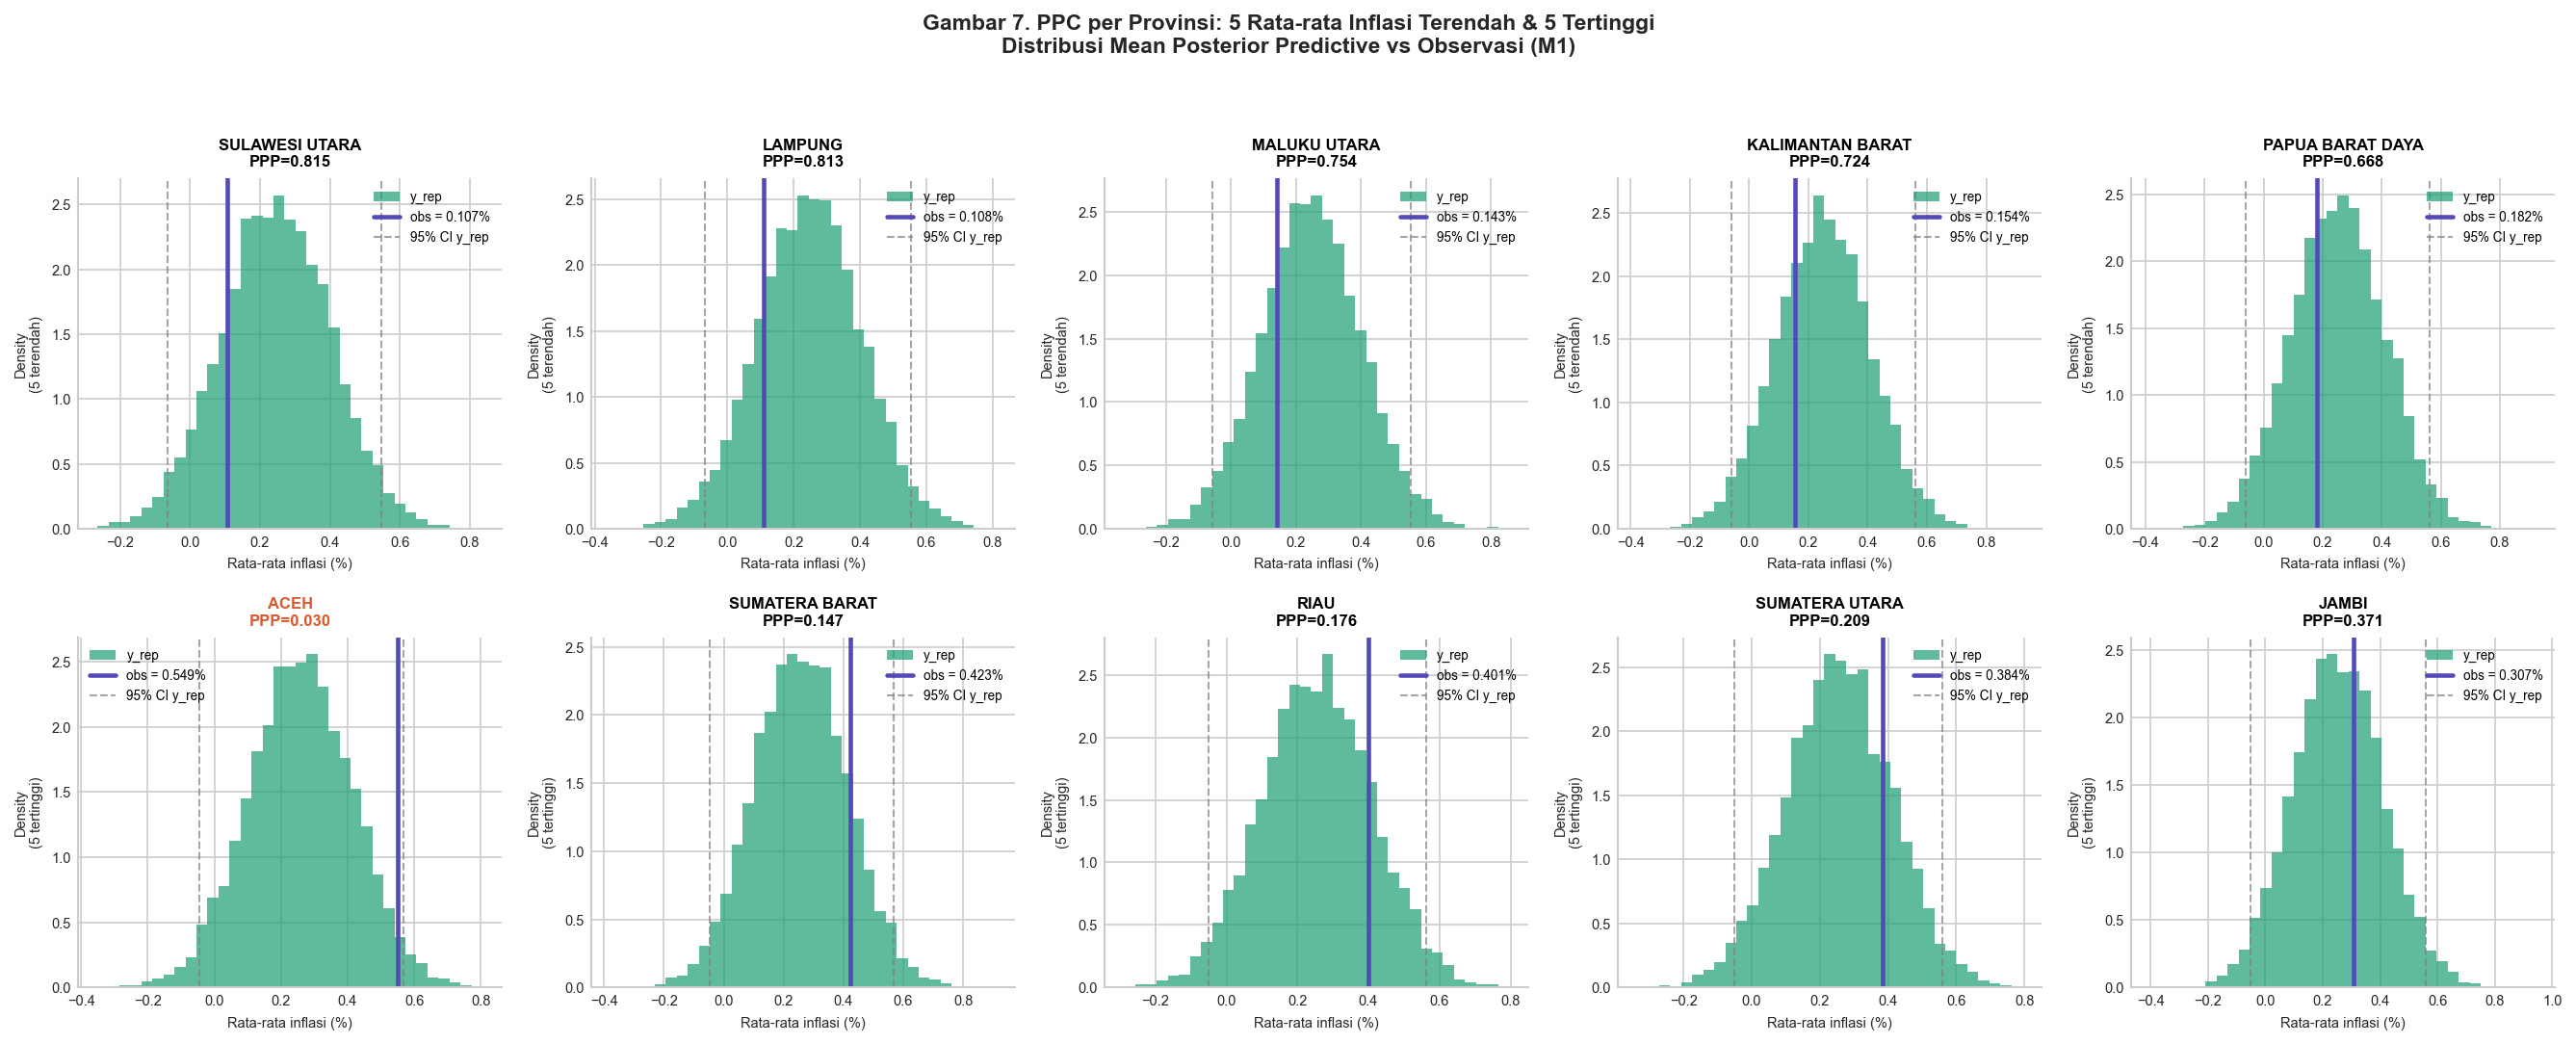


=== PPP MEAN PER PROVINSI (semua 38) ===
Provinsi                              Obs Mean   Rep Mean      PPP
-----------------------------------------------------------------
ACEH                                  0.5492%   0.2595% 0.0300 ← PERHATIAN
BALI                                  0.2417%   0.2509% 0.5215
BANTEN                                0.2292%   0.2490% 0.5500
BENGKULU                              0.2300%   0.2495% 0.5463
DI YOGYAKARTA                         0.2575%   0.2524% 0.4856
DKI JAKARTA                           0.2200%   0.2493% 0.5763
GORONTALO                             0.2158%   0.2493% 0.5865
JAMBI                                 0.3067%   0.2525% 0.3708
JAWA BARAT                            0.2192%   0.2541% 0.5881
JAWA TENGAH                           0.2250%   0.2483% 0.5544
JAWA TIMUR                            0.2425%   0.2517% 0.5291
KALIMANTAN BARAT                      0.1542%   0.2496% 0.7235
KALIMANTAN SELATAN                    0.3017%   0.2543% 0

In [54]:
print("\n=== PPC PER PROVINSI ===")

prov_obs_mean = np.array([y_obs[provinsi_idx == i].mean() for i in range(n_provinsi)])
top5_idx      = np.argsort(prov_obs_mean)[-5:][::-1]
bot5_idx      = np.argsort(prov_obs_mean)[:5]
sel_idx       = np.concatenate([bot5_idx, top5_idx])
sel_names     = [
    provinsi_list[i].replace("PROV. ", "").replace("PROV ", "")
    for i in sel_idx
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes_flat = axes.flatten()

for plot_i, prov_i in enumerate(sel_idx):
    mask      = (provinsi_idx == prov_i)
    y_prov    = y_obs[mask]
    rep_means = y_rep[:, mask].mean(axis=1)
    obs_mean  = y_prov.mean()
    ppp_local = np.mean(rep_means > obs_mean)

    ax = axes_flat[plot_i]
    ax.hist(rep_means, bins=35, color="#1D9E75", alpha=0.7, density=True, label="y_rep")
    ax.axvline(obs_mean, color="#534AB7", linewidth=2.2, label=f"obs = {obs_mean:.3f}%")
    ax.axvline(np.percentile(rep_means, 2.5),  color="gray", linewidth=1,
               linestyle="--", alpha=0.7)
    ax.axvline(np.percentile(rep_means, 97.5), color="gray", linewidth=1,
               linestyle="--", alpha=0.7, label="95% CI y_rep")

    title_color = "#D85A30" if (ppp_local < 0.1 or ppp_local > 0.9) else "black"
    ax.set_title(f"{sel_names[plot_i]}\nPPP={ppp_local:.3f}",
                 fontsize=8, fontweight="bold", color=title_color)
    ax.legend(fontsize=6.5, labelcolor="black",     # ← tambahan
              facecolor="white", framealpha=1,       # ← tambahan
              edgecolor="gray")                      # ← tambahan
    ax.set_xlabel("Rata-rata inflasi (%)", fontsize=7)
    ax.tick_params(labelsize=7)

for col in range(5):
    axes[0, col].set_ylabel("Density\n(5 terendah)", fontsize=7)
    axes[1, col].set_ylabel("Density\n(5 tertinggi)", fontsize=7)

plt.suptitle(
    "Gambar 7. PPC per Provinsi: 5 Rata-rata Inflasi Terendah & 5 Tertinggi\n"
    "Distribusi Mean Posterior Predictive vs Observasi (M1)",
    fontweight="bold", y=1.03, fontsize=11
)
plt.tight_layout()
plt.savefig("fig7_ppc_provinsi.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n=== PPP MEAN PER PROVINSI (semua 38) ===")
print(f"{'Provinsi':<35} {'Obs Mean':>10} {'Rep Mean':>10} {'PPP':>8}")
print("-" * 65)
for i in range(n_provinsi):
    mask  = (provinsi_idx == i)
    y_p   = y_obs[mask]
    rep_m = y_rep[:, mask].mean(axis=1)
    ppp_p = np.mean(rep_m > y_p.mean())
    flag  = " ← PERHATIAN" if (ppp_p < 0.1 or ppp_p > 0.9) else ""
    print(f"{provinsi_list[i].replace('PROV ',''):<35}"
          f" {y_p.mean():>8.4f}%"
          f" {rep_m.mean():>8.4f}%"
          f" {ppp_p:>6.4f}{flag}")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\1952556698.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


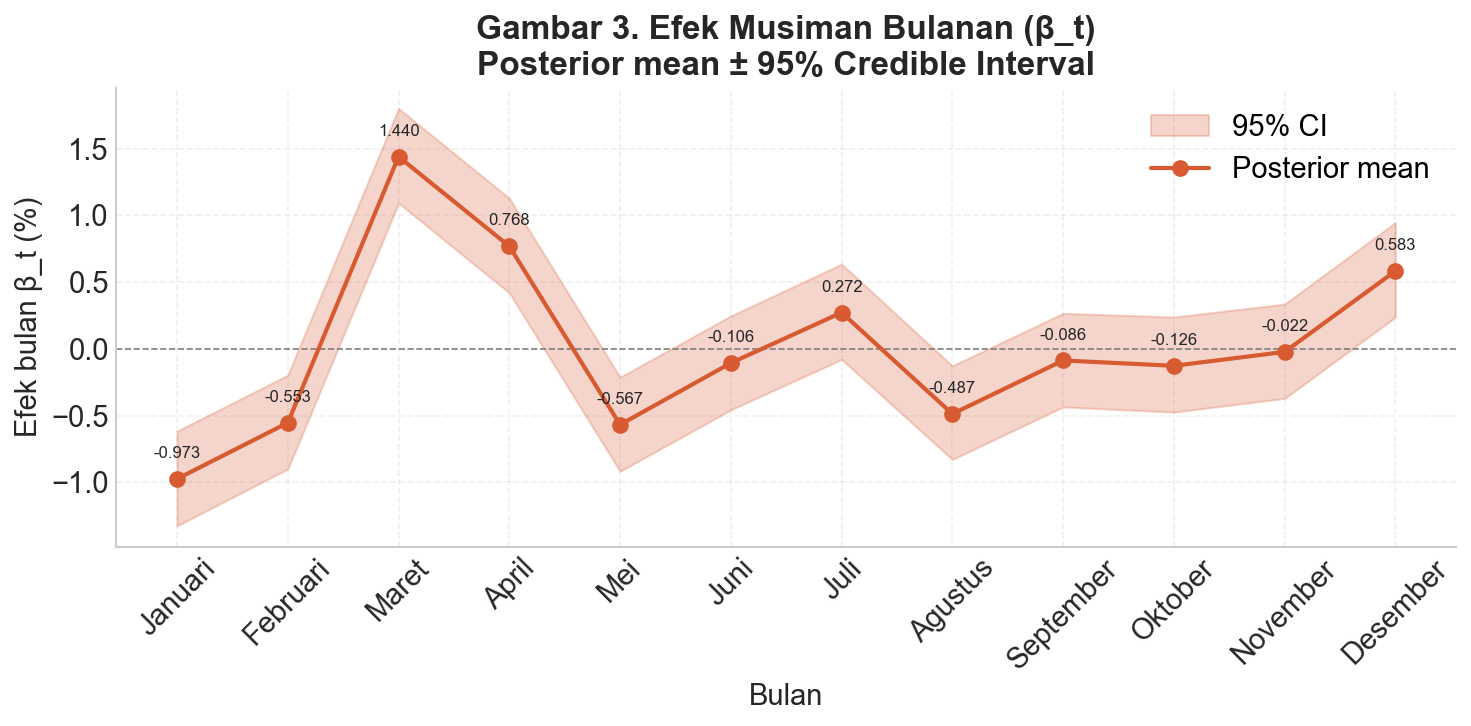

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\1952556698.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


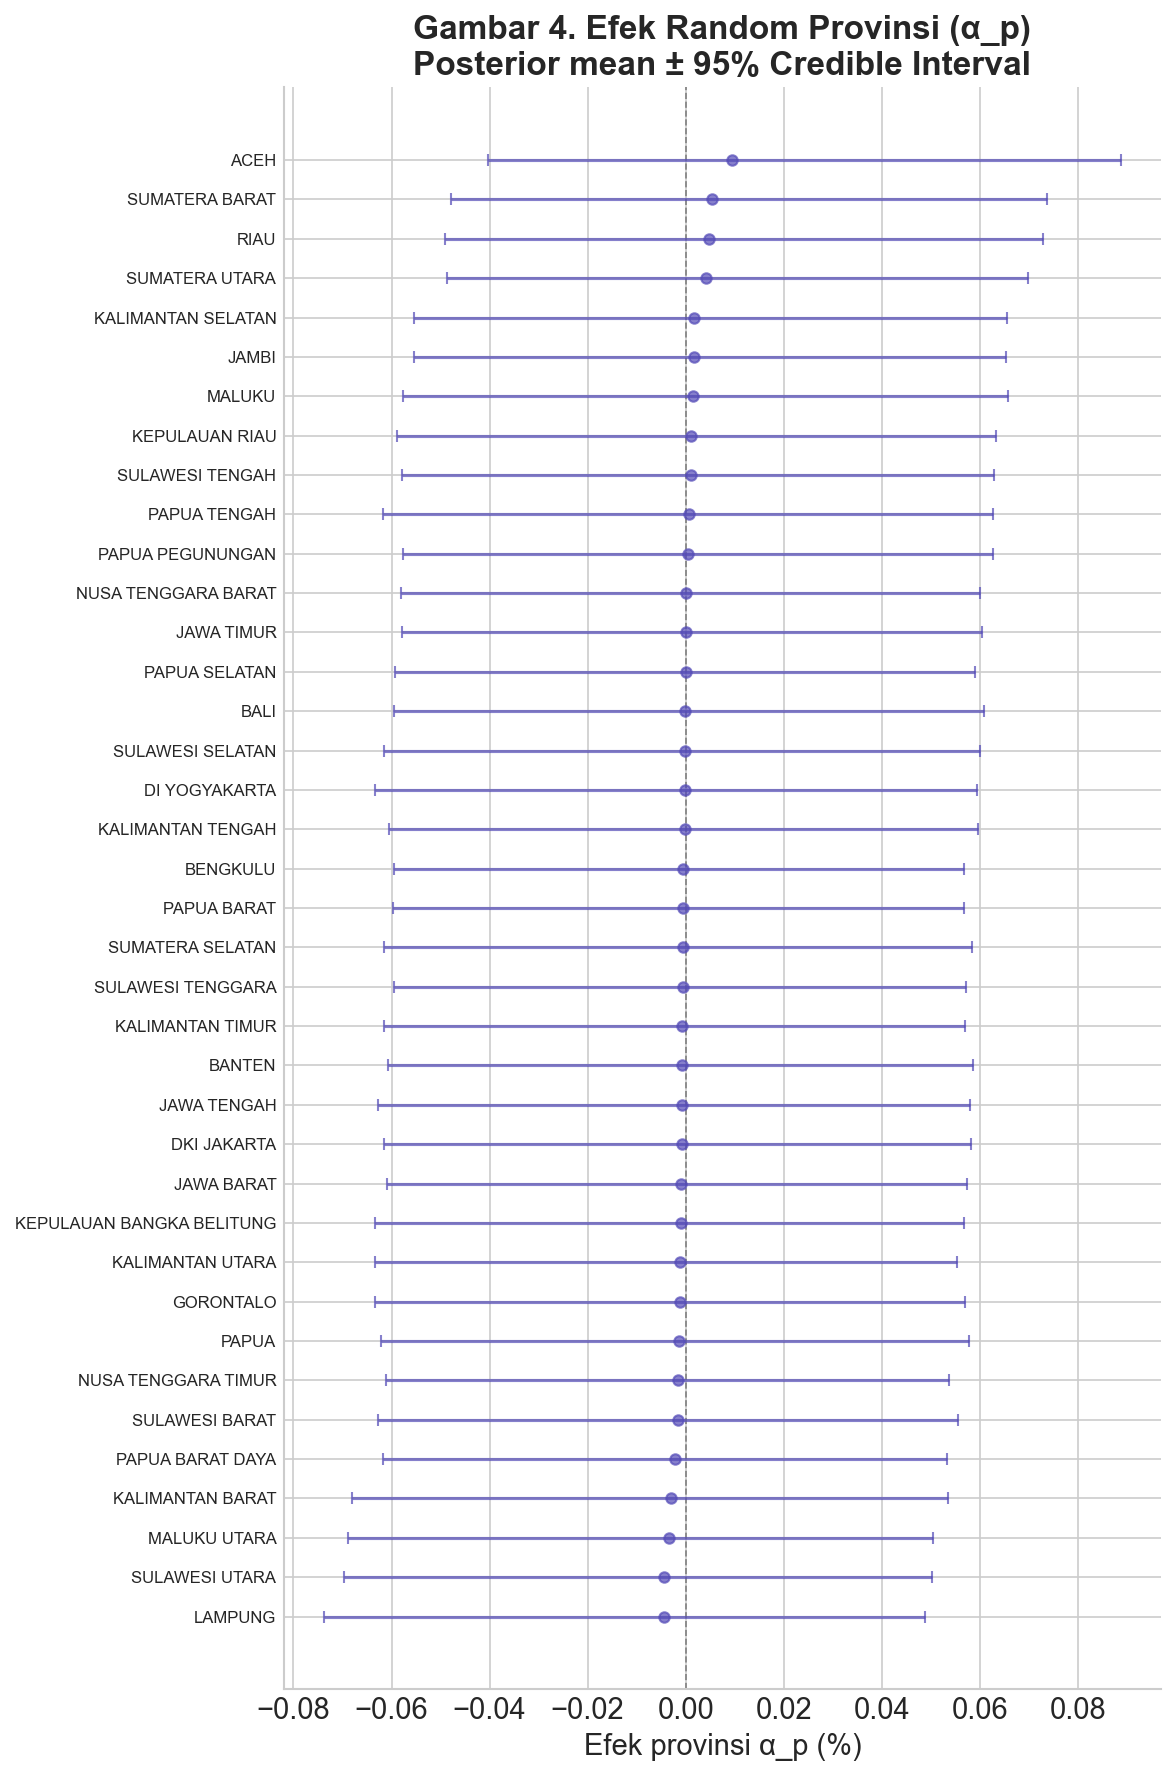

In [55]:
# --- Efek bulan (β_t) ---
beta_posterior = idata_m1.posterior["beta_t"].values
beta_posterior = beta_posterior.reshape(-1, n_bulan)
beta_mean = beta_posterior.mean(axis=0)
beta_lo   = np.percentile(beta_posterior, 2.5,  axis=0)
beta_hi   = np.percentile(beta_posterior, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.fill_between(urutan_bulan, beta_lo, beta_hi,
                alpha=0.25, color="#D85A30", label="95% CI")
ax.plot(urutan_bulan, beta_mean, marker="o",
        color="#D85A30", linewidth=2, markersize=7, label="Posterior mean")
for i, (m, v) in enumerate(zip(urutan_bulan, beta_mean)):
    ax.annotate(f"{v:.3f}", (m, v),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)
ax.set_title("Gambar 3. Efek Musiman Bulanan (β_t)\n"
             "Posterior mean ± 95% Credible Interval",
             fontweight="bold")
ax.set_xlabel("Bulan")
ax.set_ylabel("Efek bulan β_t (%)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3, linestyle="--")
ax.legend(labelcolor="black", facecolor="white",    # ← tambahan
          framealpha=1, edgecolor="gray")           # ← tambahan
plt.tight_layout()
plt.savefig("fig3_efek_bulan.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Efek provinsi (α_p) ---
alpha_posterior = idata_m1.posterior["alpha_p"].values
alpha_posterior = alpha_posterior.reshape(-1, n_provinsi)
alpha_mean = alpha_posterior.mean(axis=0)
alpha_lo   = np.percentile(alpha_posterior, 2.5,  axis=0)
alpha_hi   = np.percentile(alpha_posterior, 97.5, axis=0)

urut_idx = np.argsort(alpha_mean)

fig, ax = plt.subplots(figsize=(8, 12))
y_pos = np.arange(n_provinsi)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.errorbar(
    alpha_mean[urut_idx], y_pos,
    xerr = [alpha_mean[urut_idx] - alpha_lo[urut_idx],
            alpha_hi[urut_idx]   - alpha_mean[urut_idx]],
    fmt="o", color="#534AB7", ecolor="#534AB7",
    alpha=0.7, capsize=3, markersize=5
)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [provinsi_list[i].replace("PROV ", "") for i in urut_idx],
    fontsize=8
)
ax.set_title("Gambar 4. Efek Random Provinsi (α_p)\n"
             "Posterior mean ± 95% Credible Interval",
             fontweight="bold")
ax.set_xlabel("Efek provinsi α_p (%)")
plt.tight_layout()
plt.savefig("fig4_efek_provinsi.png", dpi=300, bbox_inches="tight")
plt.show()


=== TABEL SENSITIVITY ANALYSIS ===
                     Model  μ_global mean  μ_global SD  μ_global 2.5%  μ_global 97.5%  σ_prov mean  σ_bulan mean  σ_resid mean
   M1: Informatif + Normal         0.2390       0.1610        -0.0837          0.5511       0.0227        0.5859        0.5288
         M2: Weak + Normal         0.2422       0.1963        -0.1517          0.6297       0.0243        0.6849        0.5303
         M3: Flat + Normal         0.2572       0.2307        -0.2028          0.7032       0.0247        0.7606        0.5311
M4: Informatif + Student-t         0.2158       0.1597        -0.0973          0.5346       0.0197        0.5849        0.3561
      M5: Weak + Student-t         0.2260       0.1959        -0.1620          0.6064       0.0208        0.6832        0.3582
      M6: Flat + Student-t         0.2370       0.2370        -0.2328          0.7028       0.0211        0.7697        0.3584

Tabel tersimpan: tabel_sensitivity.csv


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\1492874340.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


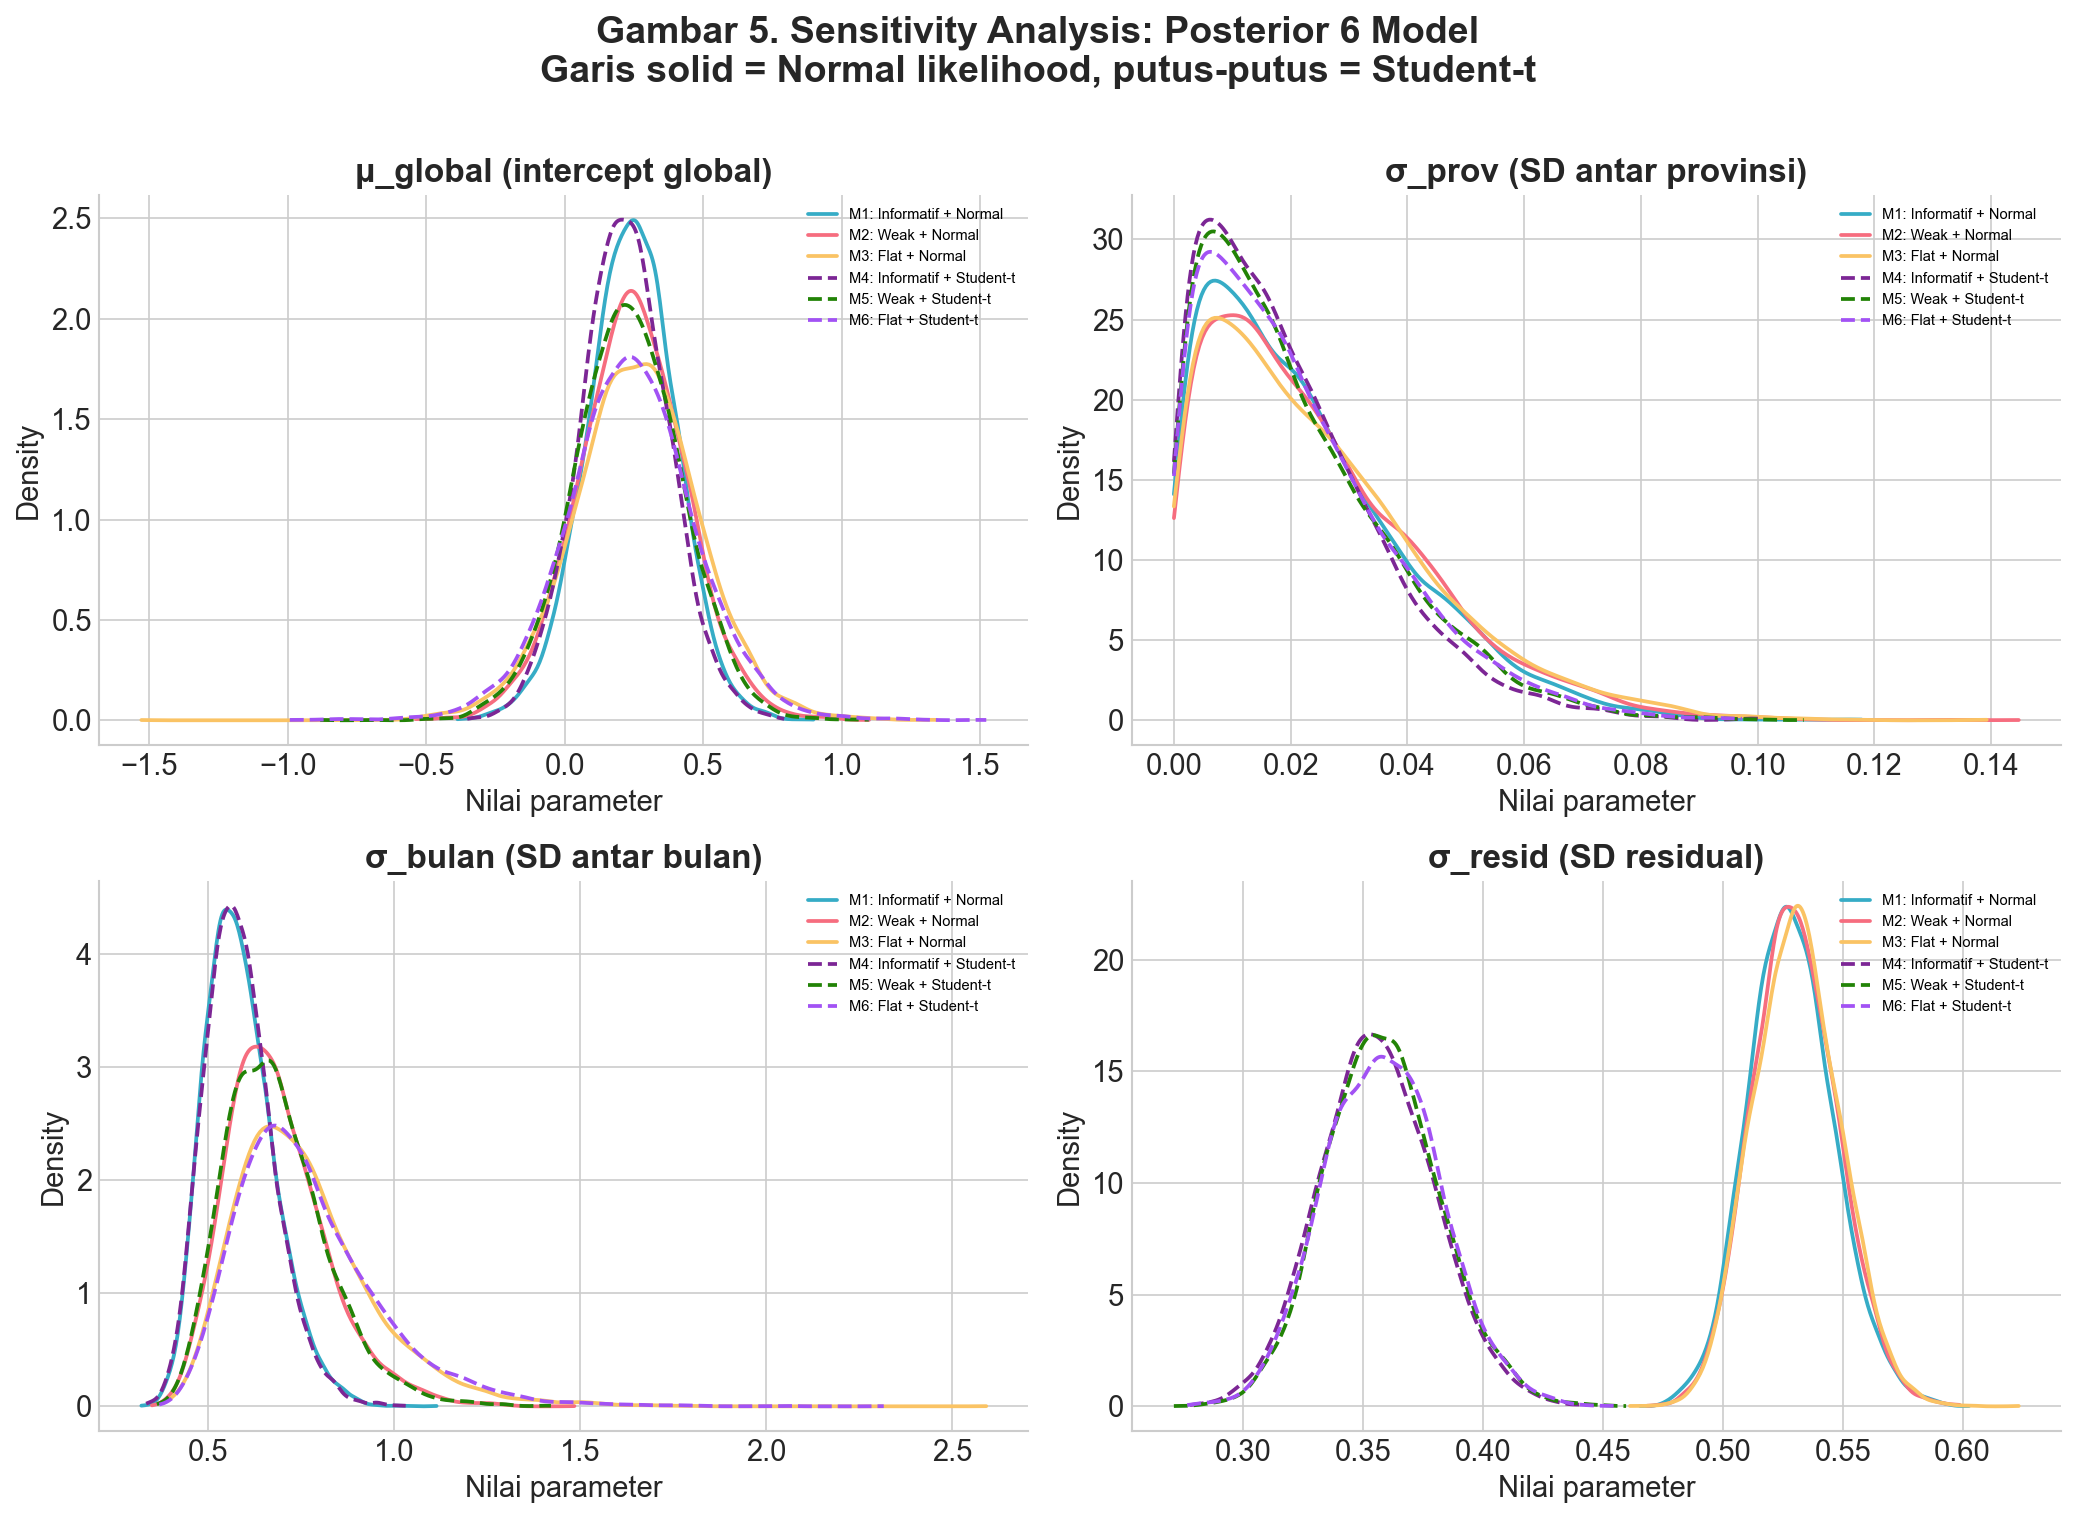

In [56]:
# --- 10.1 Ekstrak parameter utama dari semua model ---
rows = []
for nama, idata in idata_all.items():
    post = idata.posterior
    rows.append({
        "Model"          : nama,
        "μ_global mean"  : float(post["mu_global"].mean()),
        "μ_global SD"    : float(post["mu_global"].std()),
        "μ_global 2.5%"  : float(np.percentile(post["mu_global"].values, 2.5)),
        "μ_global 97.5%" : float(np.percentile(post["mu_global"].values, 97.5)),
        "σ_prov mean"    : float(post["sigma_prov"].mean()),
        "σ_bulan mean"   : float(post["sigma_bulan"].mean()),
        "σ_resid mean"   : float(post["sigma_resid"].mean()),
    })
tabel_sensitivity = pd.DataFrame(rows).round(4)
print("\n=== TABEL SENSITIVITY ANALYSIS ===")
print(tabel_sensitivity.to_string(index=False))
tabel_sensitivity.to_csv("tabel_sensitivity.csv", index=False)
print("\nTabel tersimpan: tabel_sensitivity.csv")

# --- 10.2 FIGUR 5: Plot perbandingan posterior 6 model ---
params_plot = [
    ("mu_global",   "μ_global (intercept global)", "#1D9E75"),
    ("sigma_prov",  "σ_prov (SD antar provinsi)",  "#534AB7"),
    ("sigma_bulan", "σ_bulan (SD antar bulan)",    "#D85A30"),
    ("sigma_resid", "σ_resid (SD residual)",       "#BA7517"),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (param, label, warna) in zip(axes, params_plot):
    for nama, idata in idata_all.items():
        vals = idata.posterior[param].values.flatten()
        kde  = stats.gaussian_kde(vals)
        x_g  = np.linspace(vals.min(), vals.max(), 300)
        ls   = "-" if "Normal" in nama else "--"
        ax.plot(x_g, kde(x_g), linewidth=1.8, linestyle=ls, label=nama)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Nilai parameter")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, labelcolor="black",       # ← tambahan
              facecolor="white", framealpha=1,      # ← tambahan
              edgecolor="gray")                     # ← tambahan
plt.suptitle(
    "Gambar 5. Sensitivity Analysis: Posterior 6 Model\n"
    "Garis solid = Normal likelihood, putus-putus = Student-t",
    fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig5_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()


=== SENSITIVITY: VISUALISASI LANJUTAN ===


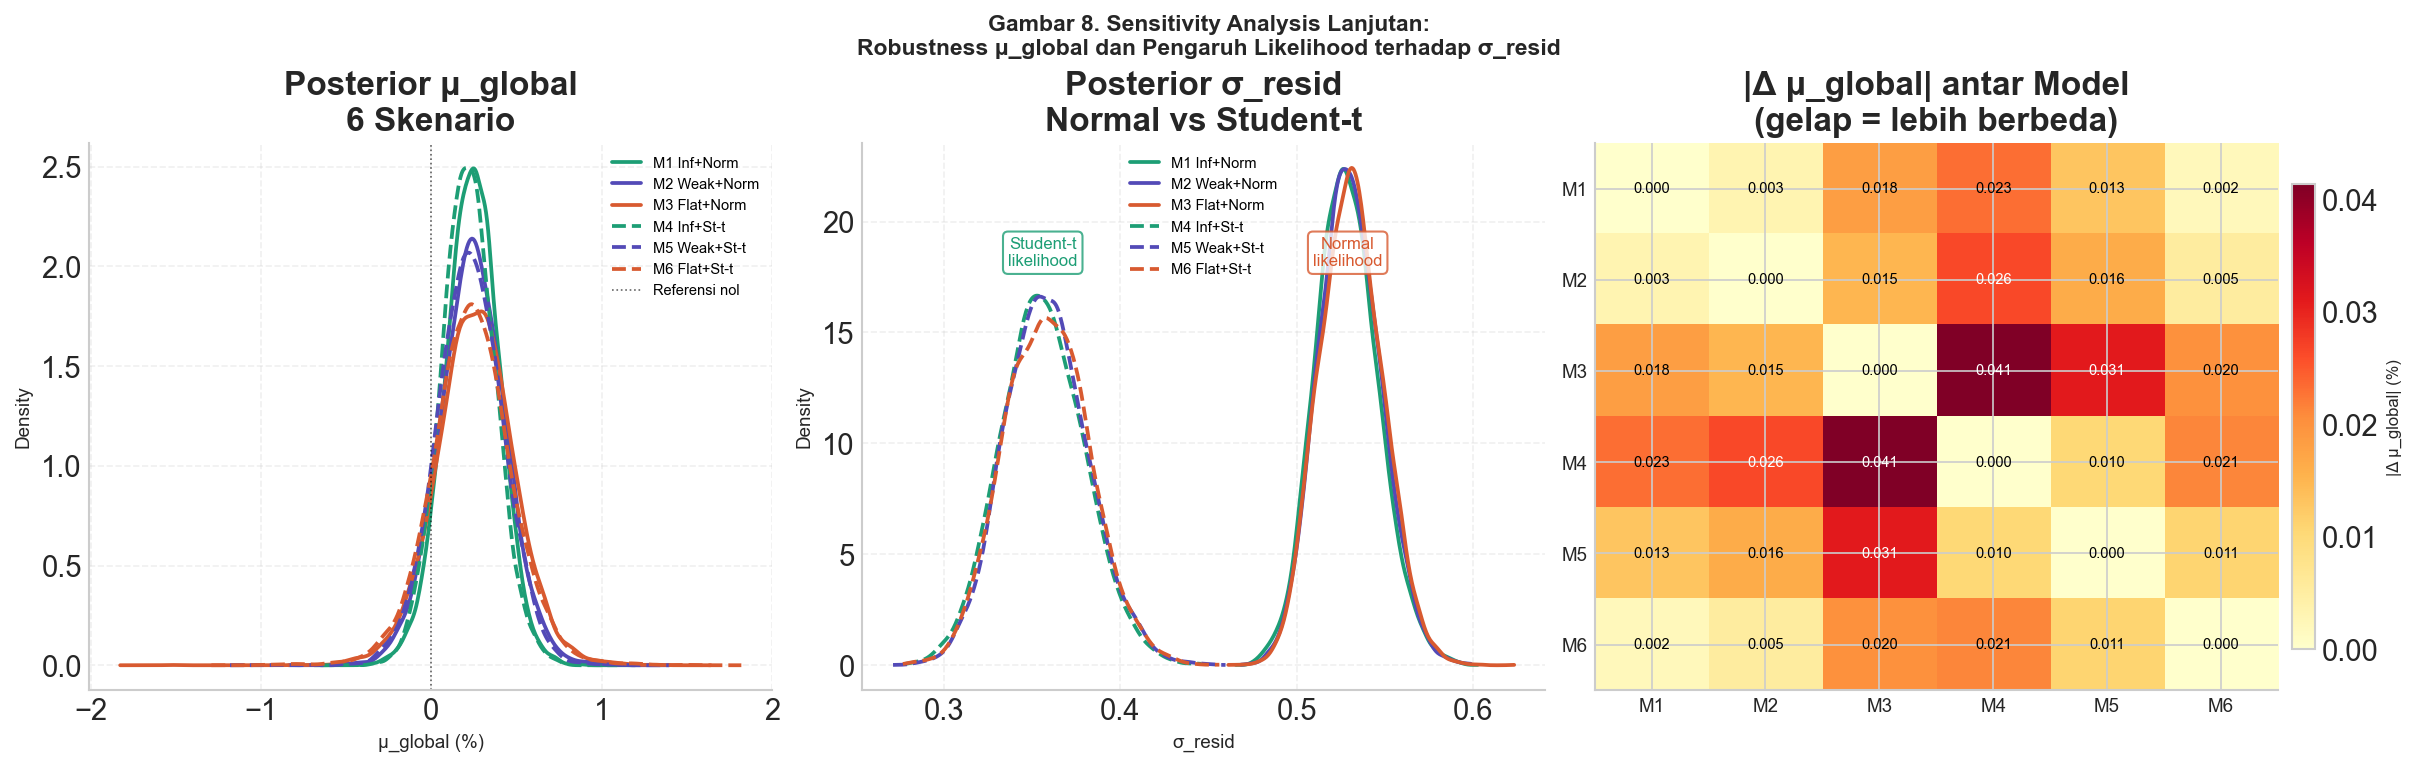

Tersimpan: fig8_sensitivity_lanjutan.png


In [57]:
print("\n=== SENSITIVITY: VISUALISASI LANJUTAN ===")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

warna_map = {
    "M1: Informatif + Normal"   : ("#1D9E75", "-",  "M1 Inf+Norm"),
    "M2: Weak + Normal"         : ("#534AB7", "-",  "M2 Weak+Norm"),
    "M3: Flat + Normal"         : ("#D85A30", "-",  "M3 Flat+Norm"),
    "M4: Informatif + Student-t": ("#1D9E75", "--", "M4 Inf+St-t"),
    "M5: Weak + Student-t"      : ("#534AB7", "--", "M5 Weak+St-t"),
    "M6: Flat + Student-t"      : ("#D85A30", "--", "M6 Flat+St-t"),
}

# Panel 1: Overlay posterior μ_global
ax = axes[0]
for nama, idata in idata_all.items():
    vals = idata.posterior["mu_global"].values.flatten()
    kde  = stats.gaussian_kde(vals)
    xg   = np.linspace(vals.min() - 0.3, vals.max() + 0.3, 300)
    c, ls, lbl = warna_map[nama]
    ax.plot(xg, kde(xg), color=c, linestyle=ls, linewidth=1.8, label=lbl)
ax.axvline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6, label="Referensi nol")
ax.set_title("Posterior μ_global\n6 Skenario", fontweight="bold")
ax.set_xlabel("μ_global (%)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=7, loc="upper right", labelcolor="black",    # ← tambahan
          facecolor="white", framealpha=1, edgecolor="gray")    # ← tambahan
ax.grid(alpha=0.3, linestyle="--")

# Panel 2: Overlay posterior σ_resid
ax = axes[1]
for nama, idata in idata_all.items():
    vals = idata.posterior["sigma_resid"].values.flatten()
    kde  = stats.gaussian_kde(vals)
    xg   = np.linspace(vals.min(), vals.max(), 300)
    c, ls, lbl = warna_map[nama]
    ax.plot(xg, kde(xg), color=c, linestyle=ls, linewidth=1.8, label=lbl)
ax.annotate("Normal\nlikelihood", xy=(0.529, 18), fontsize=8, color="#D85A30",
            ha="center", bbox=dict(boxstyle="round", fc="white", ec="#D85A30", alpha=0.8))
ax.annotate("Student-t\nlikelihood", xy=(0.356, 18), fontsize=8, color="#1D9E75",
            ha="center", bbox=dict(boxstyle="round", fc="white", ec="#1D9E75", alpha=0.8))
ax.set_title("Posterior σ_resid\nNormal vs Student-t", fontweight="bold")
ax.set_xlabel("σ_resid", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=7, labelcolor="black",           # ← tambahan
          facecolor="white", framealpha=1,          # ← tambahan
          edgecolor="gray")                         # ← tambahan
ax.grid(alpha=0.3, linestyle="--")

# Panel 3: Heatmap |Δ μ_global|
ax = axes[2]
mu_means_list = [float(idata_all[n].posterior["mu_global"].mean()) for n in idata_all]
mu_mat = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        mu_mat[i, j] = abs(mu_means_list[i] - mu_means_list[j])

model_labels = ["M1", "M2", "M3", "M4", "M5", "M6"]
im   = ax.imshow(mu_mat, cmap="YlOrRd", aspect="auto")
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("|Δ μ_global| (%)", fontsize=8)
ax.set_xticks(range(6)); ax.set_xticklabels(model_labels, fontsize=9)
ax.set_yticks(range(6)); ax.set_yticklabels(model_labels, fontsize=9)
ax.set_title("|Δ μ_global| antar Model\n(gelap = lebih berbeda)", fontweight="bold")
for i in range(6):
    for j in range(6):
        txt_color = "white" if mu_mat[i, j] > 0.025 else "black"
        ax.text(j, i, f"{mu_mat[i,j]:.3f}", ha="center", va="center",
                fontsize=7, color=txt_color)

fig.suptitle(
    "Gambar 8. Sensitivity Analysis Lanjutan:\n"
    "Robustness μ_global dan Pengaruh Likelihood terhadap σ_resid",
    fontweight="bold", fontsize=11
)
plt.savefig("fig8_sensitivity_lanjutan.png", dpi=300, bbox_inches="tight")
plt.show()
print("Tersimpan: fig8_sensitivity_lanjutan.png")


PERBANDINGAN MODEL MENGGUNAKAN LOO-CV

M1: Informatif + Normal
  ELPD LOO : -366.15
  p_LOO    : nan
  SE       : 28.72

M2: Weak + Normal
  ELPD LOO : -365.98
  p_LOO    : nan
  SE       : 28.44

M3: Flat + Normal
  ELPD LOO : -366.20
  p_LOO    : nan
  SE       : 28.47

M4: Informatif + Student-t
  ELPD LOO : -327.26
  p_LOO    : nan
  SE       : 21.94

M5: Weak + Student-t
  ELPD LOO : -327.41
  p_LOO    : nan
  SE       : 21.89

M6: Flat + Student-t
  ELPD LOO : -327.40
  p_LOO    : nan
  SE       : 21.89

TABEL PERBANDINGAN MODEL
                            rank   elpd     p  elpd_diff  weight    se    dse  warning
M4: Informatif + Student-t     0 -330.0  15.9        0.0    0.93  22.0   0.00    False
M6: Flat + Student-t           1 -330.0  16.1       -0.1    0.00  22.0   0.31    False
M5: Weak + Student-t           2 -330.0  16.1       -0.1    0.00  22.0   0.23    False
M2: Weak + Normal              3 -370.0  16.2      -40.0    0.00  28.0  15.00    False
M1: Informatif + Normal

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7052\3613276295.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


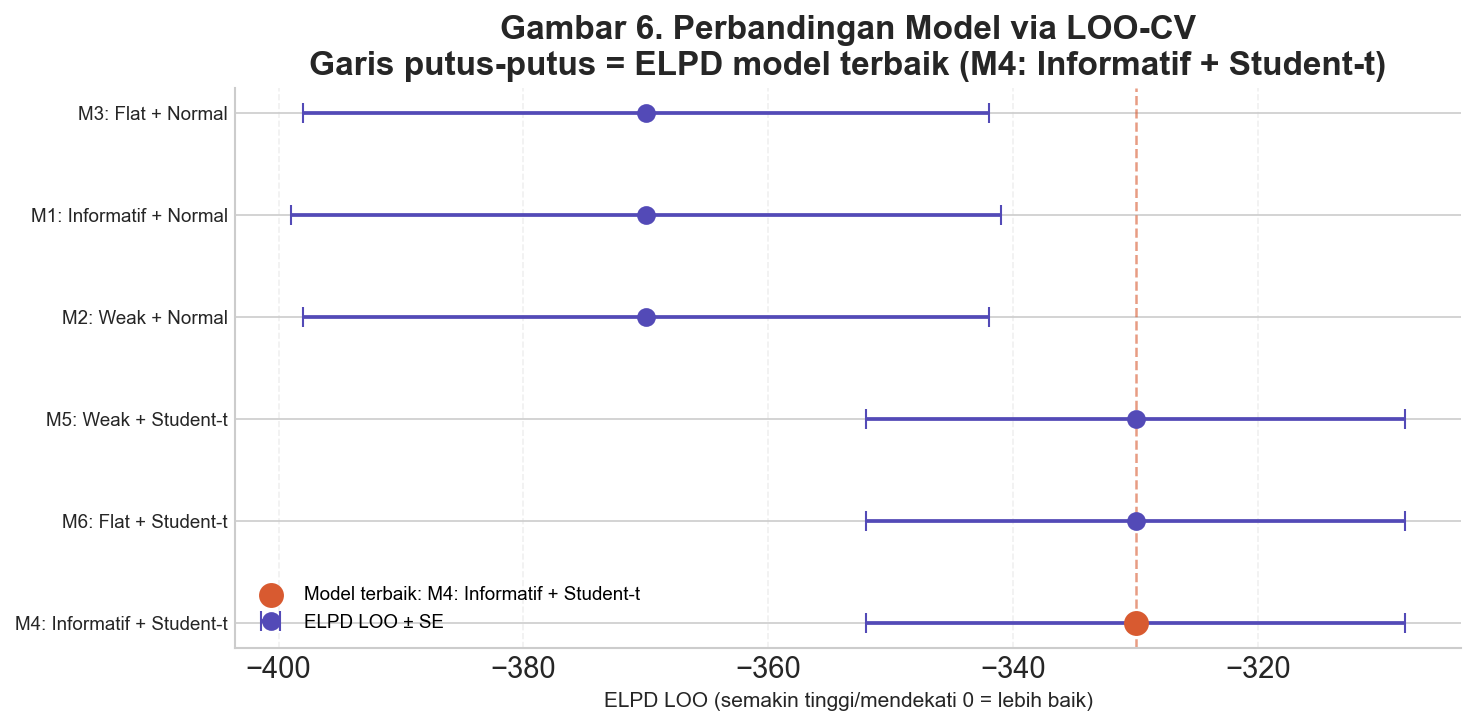

Plot LOO tersimpan: fig6_loo_compare.png


In [58]:
print("\n" + "=" * 60)
print("PERBANDINGAN MODEL MENGGUNAKAN LOO-CV")
print("=" * 60)

loo_results = {}
for nama, idata in idata_all.items():
    try:
        loo = az.loo(idata, pointwise=True)
        loo_results[nama] = loo
        elpd_val = float(getattr(loo, "elpd_loo", getattr(loo, "elpd", float("nan"))))
        p_val    = float(getattr(loo, "p_loo",    float("nan")))
        se_val   = float(getattr(loo, "se_loo",   getattr(loo, "se", float("nan"))))
        print(f"\n{nama}")
        print(f"  ELPD LOO : {elpd_val:.2f}")
        print(f"  p_LOO    : {p_val:.2f}")
        print(f"  SE       : {se_val:.2f}")
    except Exception as e:
        print(f"  {nama} GAGAL: {e}")

if not loo_results:
    print("\n[PERINGATAN] Tidak ada model yang berhasil dihitung LOO-nya.")
else:
    print("\n" + "=" * 60)
    print("TABEL PERBANDINGAN MODEL")
    print("=" * 60)
    df_compare = az.compare(loo_results)
    print(df_compare.to_string())
    df_compare.to_csv("tabel_loo_compare.csv")
    print("\nTabel tersimpan: tabel_loo_compare.csv")

    elpd_col    = "elpd_loo" if "elpd_loo" in df_compare.columns else "elpd"
    se_col      = "se_loo"   if "se_loo"   in df_compare.columns else "se"
    model_names = df_compare.index.tolist()
    elpd_vals   = df_compare[elpd_col].values
    se_vals     = df_compare[se_col].values

    y_pos = np.arange(len(model_names))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(
        elpd_vals, y_pos, xerr=se_vals,
        fmt="o", color="#534AB7", ecolor="#534AB7",
        capsize=5, markersize=8, linewidth=1.8, label="ELPD LOO ± SE"
    )
    best_idx = df_compare["rank"].values.tolist().index(0)
    ax.scatter(elpd_vals[best_idx], y_pos[best_idx], color="#D85A30", s=120, zorder=5,
               label=f"Model terbaik: {model_names[best_idx]}")
    ax.axvline(elpd_vals[best_idx], color="#D85A30", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names, fontsize=9)
    ax.set_xlabel("ELPD LOO (semakin tinggi/mendekati 0 = lebih baik)", fontsize=10)
    ax.set_title(
        "Gambar 6. Perbandingan Model via LOO-CV\n"
        f"Garis putus-putus = ELPD model terbaik ({model_names[best_idx]})",
        fontweight="bold"
    )
    ax.legend(fontsize=9, labelcolor="black",           # ← tambahan
              facecolor="white", framealpha=1,          # ← tambahan
              edgecolor="gray")                         # ← tambahan
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig6_loo_compare.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot LOO tersimpan: fig6_loo_compare.png")

In [59]:
print("\n\n" + "=" * 60)
print("RINGKASAN HASIL - MODEL 1")
print("Prior Informatif + Likelihood Normal")
print("=" * 60)

smry = az.summary(
    idata_m1,
    var_names=["mu_global", "sigma_prov", "sigma_bulan", "sigma_resid"],
    ci_prob=0.95
)
print("\n=== RINGKASAN POSTERIOR ===")
print(smry)
smry.to_csv("tabel_summary_model1.csv")

print("\n=== POSTERIOR PREDICTIVE P-VALUES (M1) ===")
print(f"PPP mean  : {ppp_m1['mean']:.4f}")
print(f"PPP SD    : {ppp_m1['sd']:.4f}")
print(f"PPP max   : {ppp_m1['max']:.4f}")
print(f"PPP min   : {ppp_m1['min']:.4f}")

print("\n=== INTERPRETASI SINGKAT ===")
for k, label in [("mean", "PPP mean"), ("sd", "PPP SD")]:
    status = "✓ baik" if 0.1 < ppp_m1[k] < 0.9 else "⚠ kurang baik"
    print(f"{label}: {status}")

lo95     = np.percentile(y_rep, 2.5,  axis=0)
hi95     = np.percentile(y_rep, 97.5, axis=0)
coverage = np.mean((y_obs >= lo95) & (y_obs <= hi95))
status   = "✓ baik" if coverage > 0.90 else "⚠ kurang baik"
print(f"Coverage interval prediksi: {coverage*100:.1f}% — {status}")

# ── EKSPOR SEMUA FILE KE FOLDER TUJUAN ──────────────────────────────────────
import os
import shutil

output_dir = r"C:/Users/ASUS/Downloads/hassil bayes"
os.makedirs(output_dir, exist_ok=True)   # buat folder jika belum ada

output_files = [
    "fig0_eda.png",
    "fig_trace_m1.png",
    "fig1_ppc_density.png",
    "fig2_ppc_bulan.png",
    "fig3_efek_bulan.png",
    "fig4_efek_provinsi.png",
    "fig5_sensitivity.png",
    "fig6_loo_compare.png",
    "fig6_qq_rootogram.png",
    "fig7_ppc_provinsi.png",
    "fig8_sensitivity_lanjutan.png",
    "tabel_sensitivity.csv",
    "tabel_loo_compare.csv",
    "tabel_summary_model1.csv",
]

print("\n=== EKSPOR FILE ===")
berhasil, gagal = 0, 0
for f in output_files:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(output_dir, f))
        print(f"  ✓ {f}")
        berhasil += 1
    else:
        print(f"  ✗ {f}  ← file tidak ditemukan, pastikan bagian sebelumnya sudah dijalankan")
        gagal += 1

print(f"\nSelesai. {berhasil} file berhasil disalin ke: {output_dir}")
if gagal > 0:
    print(f"         {gagal} file tidak ditemukan — jalankan ulang bagian yang menghasilkan file tersebut.")



RINGKASAN HASIL - MODEL 1
Prior Informatif + Likelihood Normal

=== RINGKASAN POSTERIOR ===
               mean      sd eti95_lb eti95_ub  ess_bulk  ess_tail r_hat  \
mu_global      0.24   0.161   -0.084     0.55       940      1617  1.00   
sigma_prov   0.0227  0.0174  0.00087    0.065      5156      3667  1.00   
sigma_bulan   0.586   0.093     0.43     0.79      1995      3169  1.00   
sigma_resid  0.5288  0.0179      0.5     0.57     11951      5813  1.00   

            mcse_mean  mcse_sd  
mu_global      0.0052    0.004  
sigma_prov     0.0002  0.00017  
sigma_bulan    0.0021   0.0016  
sigma_resid   0.00016  0.00012  

=== POSTERIOR PREDICTIVE P-VALUES (M1) ===
PPP mean  : 0.5021
PPP SD    : 0.4514
PPP max   : 0.0076
PPP min   : 0.0858

=== INTERPRETASI SINGKAT ===
PPP mean: ✓ baik
PPP SD: ✓ baik
Coverage interval prediksi: 95.0% — ✓ baik

=== EKSPOR FILE ===
  ✓ fig0_eda.png
  ✓ fig_trace_m1.png
  ✓ fig1_ppc_density.png
  ✓ fig2_ppc_bulan.png
  ✓ fig3_efek_bulan.png
  ✓ fig4_